# IT5006 Milestone 2: Predictive Policing in Chicago
## Team 11 — Yizhuo Zhang, Lin Xuan Foo, Yiding Cui, Yinan Jin, Xinyao Tan
### National University of Singapore · AY2025/2026 Semester 2

**Objective:** Build and evaluate predictive models to forecast crime hotspots in Chicago, enabling data-driven police resource allocation.

**Models:** Logistic Regression (baseline), Random Forest, XGBoost, LSTM

**Dataset:** Chicago Crime Data (2018-2025), 1.95M records from the Chicago Data Portal

---
## 1. Environment Setup and Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# ML Libraries
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold, GridSearchCV, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (classification_report, confusion_matrix, roc_auc_score,
                             roc_curve, accuracy_score, precision_score, recall_score, f1_score, precision_recall_curve)
import xgboost as xgb

# Deep Learning
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

# Explainability
import shap

# Holiday calendar & statistical testing
from pandas.tseries.holiday import USFederalHolidayCalendar
from scipy import stats

# Settings
plt.style.use('seaborn-v0_8-whitegrid')
pd.set_option('display.max_columns', 30)
pd.set_option('display.float_format', '{:.4f}'.format)
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
tf.random.set_seed(RANDOM_STATE)

print("Environment ready!")
print(f"NumPy: {np.__version__}")
print(f"Pandas: {pd.__version__}")
print(f"Scikit-learn: {__import__('sklearn').__version__}")
print(f"XGBoost: {xgb.__version__}")
print(f"TensorFlow: {tf.__version__}")
print(f"SHAP: {shap.__version__}")

Environment ready!
NumPy: 2.4.3
Pandas: 3.0.1
Scikit-learn: 1.8.0
XGBoost: 3.2.0
TensorFlow: 2.21.0
SHAP: 0.51.0


---
## 2. Data Loading and Initial Exploration

We load the Chicago crime dataset (2018-2025) from the Chicago Data Portal. The dataset contains over 1.9 million crime incident records with spatial, temporal, and categorical information.

In [2]:
# Data source switch: prefer local file by default; enable download only when needed
import os, requests, time

USE_ONLINE_DOWNLOAD = False
LOCAL_CSV_CANDIDATES = [
    'data/chicago_crimes_2018_2025.csv',
    'data/chicago_crime_2018_2025.csv',
]

os.makedirs('data', exist_ok=True)
csv_path = None
for cand in LOCAL_CSV_CANDIDATES:
    if os.path.exists(cand):
        csv_path = cand
        break
if csv_path is None:
    csv_path = LOCAL_CSV_CANDIDATES[0]

if not USE_ONLINE_DOWNLOAD:
    if not os.path.exists(csv_path):
        raise FileNotFoundError(
            f"No local file found in {LOCAL_CSV_CANDIDATES}. Set USE_ONLINE_DOWNLOAD=True to fetch from portal."
        )
    print(f"Using local data file: {csv_path}")
else:
    if os.path.exists(csv_path):
        print(f'Data already exists at {csv_path}, skipping download.')
    else:
        print(' Downloading from Chicago Data Portal (this may take a few minutes)...')
        BASE = 'https://data.cityofchicago.org/resource/ijzp-q8t2.csv'
        LIMIT = 50000
        WHERE = "date >= '2018-01-01T00:00:00'"

        all_chunks = []
        offset = 0
        while True:
            params = {
                '$where': WHERE,
                '$limit': LIMIT,
                '$offset': offset,
                '$order': ':id'
            }
            r = requests.get(BASE, params=params, timeout=120)
            r.raise_for_status()
            chunk = r.text
            n_rows = chunk.count('\n') - 1
            if offset == 0:
                all_chunks.append(chunk)
            else:
                all_chunks.append(chunk.split('\n', 1)[1])
            print(f'  Fetched rows {offset:,} - {offset + n_rows:,}')
            if n_rows < LIMIT:
                break
            offset += LIMIT
            time.sleep(1)

        with open(csv_path, 'w') as f:
            f.write(''.join(all_chunks))
        print(f' Saved to {csv_path}')


Using local data file: data/chicago_crime_2018_2025.csv


In [3]:
import pandas as pd
print(pd.read_csv(csv_path, nrows=2).columns.tolist())


['id', 'case_number', 'date', 'block', 'iucr', 'primary_type', 'description', 'location_description', 'arrest', 'domestic', 'beat', 'district', 'ward', 'community_area', 'fbi_code', 'x_coordinate', 'y_coordinate', 'year', 'updated_on', 'latitude', 'longitude', 'location']


In [4]:
df = pd.read_csv(csv_path)
df.columns = df.columns.str.strip()

# Rename SODA API lowercase columns to expected format
if 'date' in df.columns:
    RENAME_MAP = {
        'id': 'ID', 'case_number': 'Case Number', 'date': 'Date',
        'block': 'Block', 'iucr': 'IUCR', 'primary_type': 'Primary Type',
        'description': 'Description', 'location_description': 'Location Description',
        'arrest': 'Arrest', 'domestic': 'Domestic', 'beat': 'Beat',
        'district': 'District', 'ward': 'Ward', 'community_area': 'Community Area',
        'fbi_code': 'FBI Code', 'x_coordinate': 'X Coordinate',
        'y_coordinate': 'Y Coordinate', 'year': 'Year',
        'updated_on': 'Updated On', 'latitude': 'Latitude',
        'longitude': 'Longitude', 'location': 'Location'
    }
    df.rename(columns=RENAME_MAP, inplace=True)
    print("Renamed SODA columns to expected format.")

df['Date'] = pd.to_datetime(df['Date'])
print(f"Dataset Shape: {df.shape}")
print(f"Date Range: {df['Date'].min()} to {df['Date'].max()}")
print(f"\nColumn Types:")
print(df.dtypes)
print(f"\nMissing Values (top 10):")
print(df.isnull().sum().sort_values(ascending=False).head(10))


Renamed SODA columns to expected format.


Dataset Shape: (1952048, 22)
Date Range: 2018-01-01 00:01:00 to 2025-12-31 23:58:00

Column Types:
ID                               int64
Case Number                        str
Date                    datetime64[us]
Block                              str
IUCR                               str
Primary Type                       str
Description                        str
Location Description               str
Arrest                            bool
Domestic                          bool
Beat                             int64
District                         int64
Ward                           float64
Community Area                 float64
FBI Code                           str
X Coordinate                   float64
Y Coordinate                   float64
Year                             int64
Updated On                         str
Latitude                       float64
Longitude                      float64
Location                           str
dtype: object

Missing Values (top 10):


Location                28313
Longitude               28313
Latitude                28313
Y Coordinate            28313
X Coordinate            28313
Location Description    10395
Community Area            134
Ward                       53
Updated On                  0
Year                        0
dtype: int64


In [5]:
# Quick overview of the data
print("=" * 60)
print("DATASET OVERVIEW")
print("=" * 60)
print(f"Total Records: {len(df):,}")
print(f"\nTop 10 Crime Types:")
print(df['Primary Type'].value_counts().head(10).to_string())
print(f"\nArrest Rate: {df['Arrest'].mean():.2%}")
print(f"Domestic Rate: {df['Domestic'].mean():.2%}")

DATASET OVERVIEW
Total Records: 1,952,048

Top 10 Crime Types:
Primary Type
THEFT                  437944
BATTERY                355258
CRIMINAL DAMAGE        216586
ASSAULT                168121
DECEPTIVE PRACTICE     141482
MOTOR VEHICLE THEFT    129198
OTHER OFFENSE          124867
BURGLARY                70030
ROBBERY                 68401
NARCOTICS               65204

Arrest Rate: 15.63%
Domestic Rate: 19.57%


---
## 3. Data Preprocessing and Feature Engineering

### 3.1 Data Cleaning
We remove records with invalid coordinates and classify crimes into categories: **Property**, **Violent**, **Sexual**, and **Other**.

In [6]:
# Data Cleaning
df = df.dropna(subset=['Latitude', 'Longitude', 'Community Area'])
df = df[(df['Latitude'] > 41.6) & (df['Latitude'] < 42.1)]
df = df[(df['Longitude'] > -87.95) & (df['Longitude'] < -87.5)]
print(f"After cleaning: {len(df):,} records")

# Crime Category Classification
PROPERTY = ['THEFT','BURGLARY','MOTOR VEHICLE THEFT','ROBBERY','ARSON',
            'CRIMINAL DAMAGE','DECEPTIVE PRACTICE']
VIOLENT = ['BATTERY','ASSAULT','HOMICIDE','KIDNAPPING',
           'WEAPONS VIOLATION','INTIMIDATION']
SEXUAL = ['CRIM SEXUAL ASSAULT','SEX OFFENSE','STALKING',
          'HUMAN TRAFFICKING','PROSTITUTION']

def classify_crime(pt):
    if pt in PROPERTY: return 'PROPERTY'
    elif pt in VIOLENT: return 'VIOLENT'
    elif pt in SEXUAL: return 'SEXUAL'
    else: return 'OTHER'

df['crime_category'] = df['Primary Type'].apply(classify_crime)
print(f"\nCrime Category Distribution:")
print(df['crime_category'].value_counts().to_string())
print(f"\nProperty + Violent = {(df['crime_category'].isin(['PROPERTY','VIOLENT'])).mean():.1%} of all crimes")

After cleaning: 1,923,599 records



Crime Category Distribution:
crime_category
PROPERTY    1048471
VIOLENT      588884
OTHER        268806
SEXUAL        17438

Property + Violent = 85.1% of all crimes


### 3.2 Feature Engineering

We engineer temporal, spatial, historical lag, and contextual features to capture the complex dynamics of crime patterns.

In [7]:
# Temporal + Calendar + Historical Feature Engineering (no grid-neighbor features)
df['hour'] = df['Date'].dt.hour
df['day_of_week'] = df['Date'].dt.dayofweek
df['month'] = df['Date'].dt.month
df['day_of_month'] = df['Date'].dt.day
df['quarter'] = df['Date'].dt.quarter
df['year'] = df['Date'].dt.year
df['date_only'] = df['Date'].dt.date
df['is_weekend'] = df['day_of_week'].isin([5, 6]).astype(int)
df['is_night'] = df['hour'].isin(list(range(0, 6)) + list(range(21, 24))).astype(int)
df['time_period'] = pd.cut(df['hour'], bins=[0, 6, 12, 18, 24], labels=[0, 1, 2, 3], right=False).astype(int)
df['is_payday'] = df['day_of_month'].isin([1, 15]).astype(int)

# Cyclical encodings
df['hour_sin'] = np.sin(2 * np.pi * df['hour'] / 24)
df['hour_cos'] = np.cos(2 * np.pi * df['hour'] / 24)
df['dow_sin'] = np.sin(2 * np.pi * df['day_of_week'] / 7)
df['dow_cos'] = np.cos(2 * np.pi * df['day_of_week'] / 7)

# Federal holidays + Juneteenth observed + pre/post/long-weekend
cal = USFederalHolidayCalendar()
start = df['Date'].min().normalize() - pd.Timedelta(days=7)
end = df['Date'].max().normalize() + pd.Timedelta(days=7)
us_holidays = pd.DatetimeIndex(cal.holidays(start=start, end=end))

juneteenth_obs = []
for y in range(int(df['year'].min()), int(df['year'].max()) + 1):
    if y < 2021:
        continue
    d = pd.Timestamp(year=y, month=6, day=19)
    if d.dayofweek == 5:
        d = d - pd.Timedelta(days=1)
    elif d.dayofweek == 6:
        d = d + pd.Timedelta(days=1)
    juneteenth_obs.append(d)

holidays = pd.DatetimeIndex(sorted(set(us_holidays.tolist() + juneteenth_obs)))
date_norm = df['Date'].dt.normalize()
df['is_holiday'] = date_norm.isin(holidays).astype(int)
df['is_pre_holiday'] = (date_norm + pd.Timedelta(days=1)).isin(holidays).astype(int)
df['is_post_holiday'] = (date_norm - pd.Timedelta(days=1)).isin(holidays).astype(int)
df['is_long_weekend'] = ((df['is_weekend'] == 1) | (df['is_holiday'] == 1) |
                         (df['is_pre_holiday'] == 1) | (df['is_post_holiday'] == 1)).astype(int)

# Top-K primary type bucket for one-hot encoding
top_k_types = df['Primary Type'].value_counts().nlargest(8).index
df['primary_type_topk'] = np.where(df['Primary Type'].isin(top_k_types), df['Primary Type'], 'OTHER')

# Aggregate to spatiotemporal units
agg_df = df.groupby(['Community Area', 'date_only', 'time_period', 'crime_category', 'primary_type_topk', 'year']).agg(
    crime_count=('ID', 'count'),
    hour_mean=('hour', 'mean'),
    day_of_week=('day_of_week', 'first'),
    month=('month', 'first'),
    day_of_month=('day_of_month', 'first'),
    quarter=('quarter', 'first'),
    is_weekend=('is_weekend', 'first'),
    is_night=('is_night', 'max'),
    is_payday=('is_payday', 'first'),
    is_holiday=('is_holiday', 'first'),
    is_pre_holiday=('is_pre_holiday', 'first'),
    is_post_holiday=('is_post_holiday', 'first'),
    is_long_weekend=('is_long_weekend', 'first'),
    hour_sin=('hour_sin', 'mean'),
    hour_cos=('hour_cos', 'mean'),
    dow_sin=('dow_sin', 'first'),
    dow_cos=('dow_cos', 'first'),
    lat_mean=('Latitude', 'mean'),
    lon_mean=('Longitude', 'mean')
).reset_index()

# Historical lag/trend/volatility features (shifted to avoid leakage)
daily_ca = df.groupby(['Community Area', 'date_only']).agg(
    daily_count=('ID', 'count'),
    daily_arrest=('Arrest', 'sum'),
    daily_domestic=('Domestic', 'sum')
).reset_index().sort_values(['Community Area', 'date_only'])

daily_ca['lag_1d'] = daily_ca.groupby('Community Area')['daily_count'].shift(1)
daily_ca['lag_7d'] = daily_ca.groupby('Community Area')['daily_count'].shift(7)
for win in [7, 14, 30]:
    daily_ca[f'rolling_{win}d'] = daily_ca.groupby('Community Area')['daily_count'].transform(
        lambda x: x.rolling(win, min_periods=1).mean().shift(1)
    )

daily_ca['rolling_std_7d'] = daily_ca.groupby('Community Area')['daily_count'].transform(
    lambda x: x.rolling(7, min_periods=2).std().shift(1)
)
daily_ca['rolling_std_30d'] = daily_ca.groupby('Community Area')['daily_count'].transform(
    lambda x: x.rolling(30, min_periods=2).std().shift(1)
)
daily_ca['crime_trend'] = daily_ca['rolling_7d'] / daily_ca['rolling_30d'].clip(lower=0.1)
daily_ca['spike_7_30'] = (daily_ca['rolling_7d'] - daily_ca['rolling_30d']) / daily_ca['rolling_30d'].clip(lower=0.1)

daily_ca['arrest_count'] = daily_ca.groupby('Community Area')['daily_arrest'].transform(
    lambda x: x.rolling(7, min_periods=1).sum().shift(1)
)
daily_ca['domestic_count'] = daily_ca.groupby('Community Area')['daily_domestic'].transform(
    lambda x: x.rolling(7, min_periods=1).sum().shift(1)
)

agg_df = agg_df.merge(
    daily_ca[[
        'Community Area', 'date_only',
        'lag_1d', 'lag_7d',
        'rolling_7d', 'rolling_14d', 'rolling_30d',
        'rolling_std_7d', 'rolling_std_30d',
        'crime_trend', 'spike_7_30',
        'arrest_count', 'domestic_count'
    ]],
    on=['Community Area', 'date_only'],
    how='left'
)

for col in [
    'lag_1d', 'lag_7d',
    'rolling_7d', 'rolling_14d', 'rolling_30d',
    'rolling_std_7d', 'rolling_std_30d',
    'crime_trend', 'spike_7_30',
    'arrest_count', 'domestic_count'
]:
    agg_df[col] = agg_df[col].fillna(agg_df[col].median())

# Compute target threshold from training period only (<2025)
train_agg = agg_df[agg_df['year'].astype(int) < 2025]
median_lookup = train_agg.groupby(['Community Area', 'time_period'])['crime_count'].median()
median_lookup.name = 'train_median'
agg_df = agg_df.merge(median_lookup, on=['Community Area', 'time_period'], how='left')
global_median = train_agg['crime_count'].median()
agg_df['train_median'] = agg_df['train_median'].fillna(global_median)
agg_df['high_crime'] = (agg_df['crime_count'] > agg_df['train_median']).astype(int)
agg_df.drop(columns='train_median', inplace=True)

print(f"Aggregated Dataset Shape: {agg_df.shape}")
print("\nTarget Distribution:")
print(agg_df['high_crime'].value_counts().to_string())
print(f"\nPositive Rate: {agg_df['high_crime'].mean():.2%}")
print("\n[NOTE] Target threshold computed from TRAINING data only (< 2025) to prevent leakage.")
print("\nFeature Summary:")
print(agg_df.describe().round(2).to_string())


Aggregated Dataset Shape: (1478884, 37)

Target Distribution:
high_crime
0    1175366
1     303518

Positive Rate: 20.52%

[NOTE] Target threshold computed from TRAINING data only (< 2025) to prevent leakage.

Feature Summary:


       Community Area  time_period         year  crime_count    hour_mean  day_of_week        month  day_of_month      quarter   is_weekend     is_night    is_payday   is_holiday  is_pre_holiday  is_post_holiday  is_long_weekend     hour_sin     hour_cos      dow_sin      dow_cos     lat_mean     lon_mean       lag_1d       lag_7d   rolling_7d  rolling_14d  rolling_30d  rolling_std_7d  rolling_std_30d  crime_trend   spike_7_30  arrest_count  domestic_count   high_crime
count    1478884.0000 1478884.0000 1478884.0000 1478884.0000 1478884.0000 1478884.0000 1478884.0000  1478884.0000 1478884.0000 1478884.0000 1478884.0000 1478884.0000 1478884.0000    1478884.0000     1478884.0000     1478884.0000 1478884.0000 1478884.0000 1478884.0000 1478884.0000 1478884.0000 1478884.0000 1478884.0000 1478884.0000 1478884.0000 1478884.0000 1478884.0000    1478884.0000     1478884.0000 1478884.0000 1478884.0000  1478884.0000    1478884.0000 1478884.0000
mean          37.6700       1.6700    2021.5300     

### 3.3 Feature Analysis and Correlation

Visualizing the engineered features to understand their distributions and relationships.

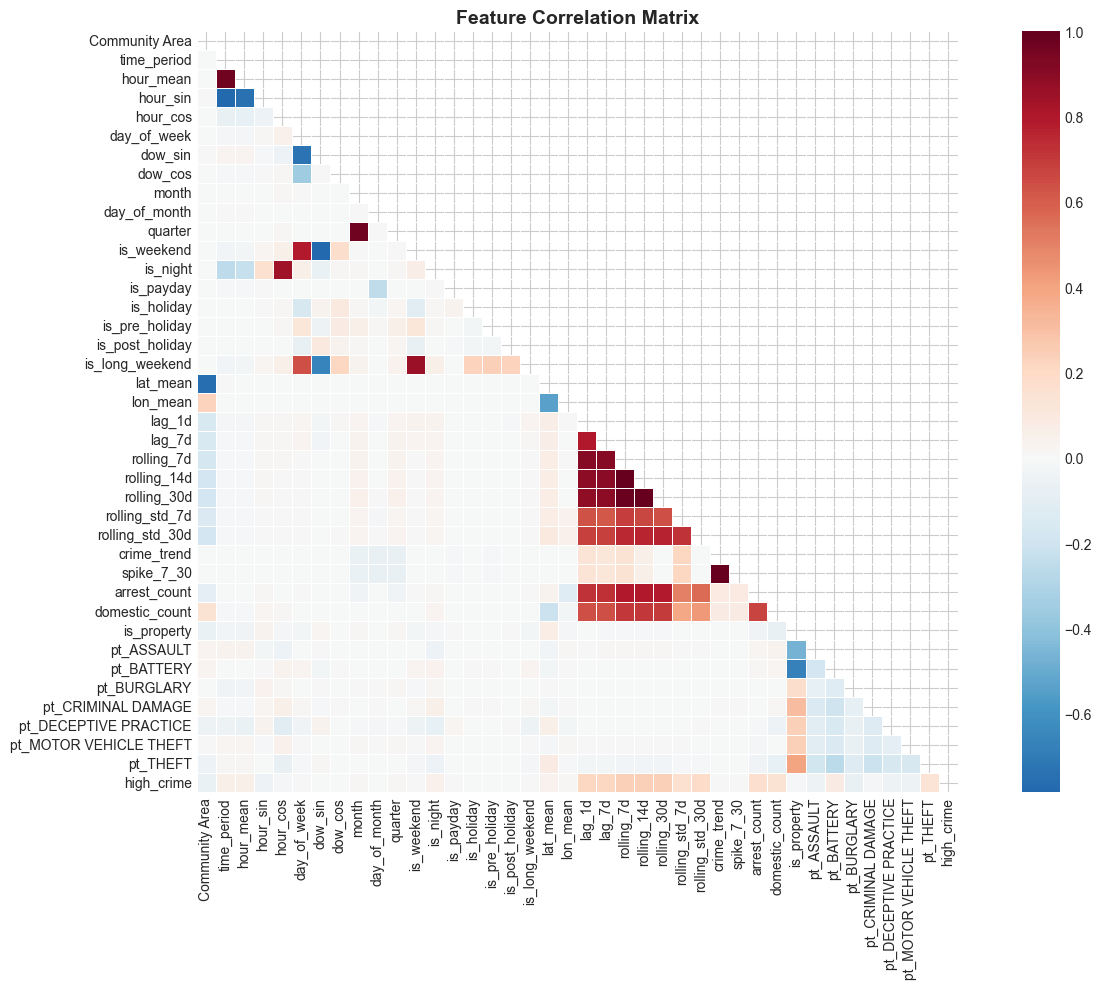

In [8]:
# Feature Correlation Heatmap + Feature List
model_df = agg_df[agg_df['crime_category'].isin(['PROPERTY', 'VIOLENT'])].copy()
model_df['is_property'] = (model_df['crime_category'] == 'PROPERTY').astype(int)

# One-hot encode top crime types retained from preprocessing
pt_dummies = pd.get_dummies(model_df['primary_type_topk'], prefix='pt', dtype=int)
if 'pt_OTHER' in pt_dummies.columns:
    pt_dummies = pt_dummies.drop(columns=['pt_OTHER'])
model_df = pd.concat([model_df, pt_dummies], axis=1)
pt_feature_cols = pt_dummies.columns.tolist()

FEATURE_COLS = [
    'Community Area', 'time_period',
    'hour_mean', 'hour_sin', 'hour_cos',
    'day_of_week', 'dow_sin', 'dow_cos',
    'month', 'day_of_month', 'quarter',
    'is_weekend', 'is_night', 'is_payday',
    'is_holiday', 'is_pre_holiday', 'is_post_holiday', 'is_long_weekend',
    'lat_mean', 'lon_mean',
    'lag_1d', 'lag_7d',
    'rolling_7d', 'rolling_14d', 'rolling_30d',
    'rolling_std_7d', 'rolling_std_30d',
    'crime_trend', 'spike_7_30',
    'arrest_count', 'domestic_count',
    'is_property'
] + pt_feature_cols

fig, ax = plt.subplots(figsize=(14, 10))
corr = model_df[FEATURE_COLS + ['high_crime']].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=False, cmap='RdBu_r', center=0,
            square=True, linewidths=0.5, ax=ax)
ax.set_title('Feature Correlation Matrix', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


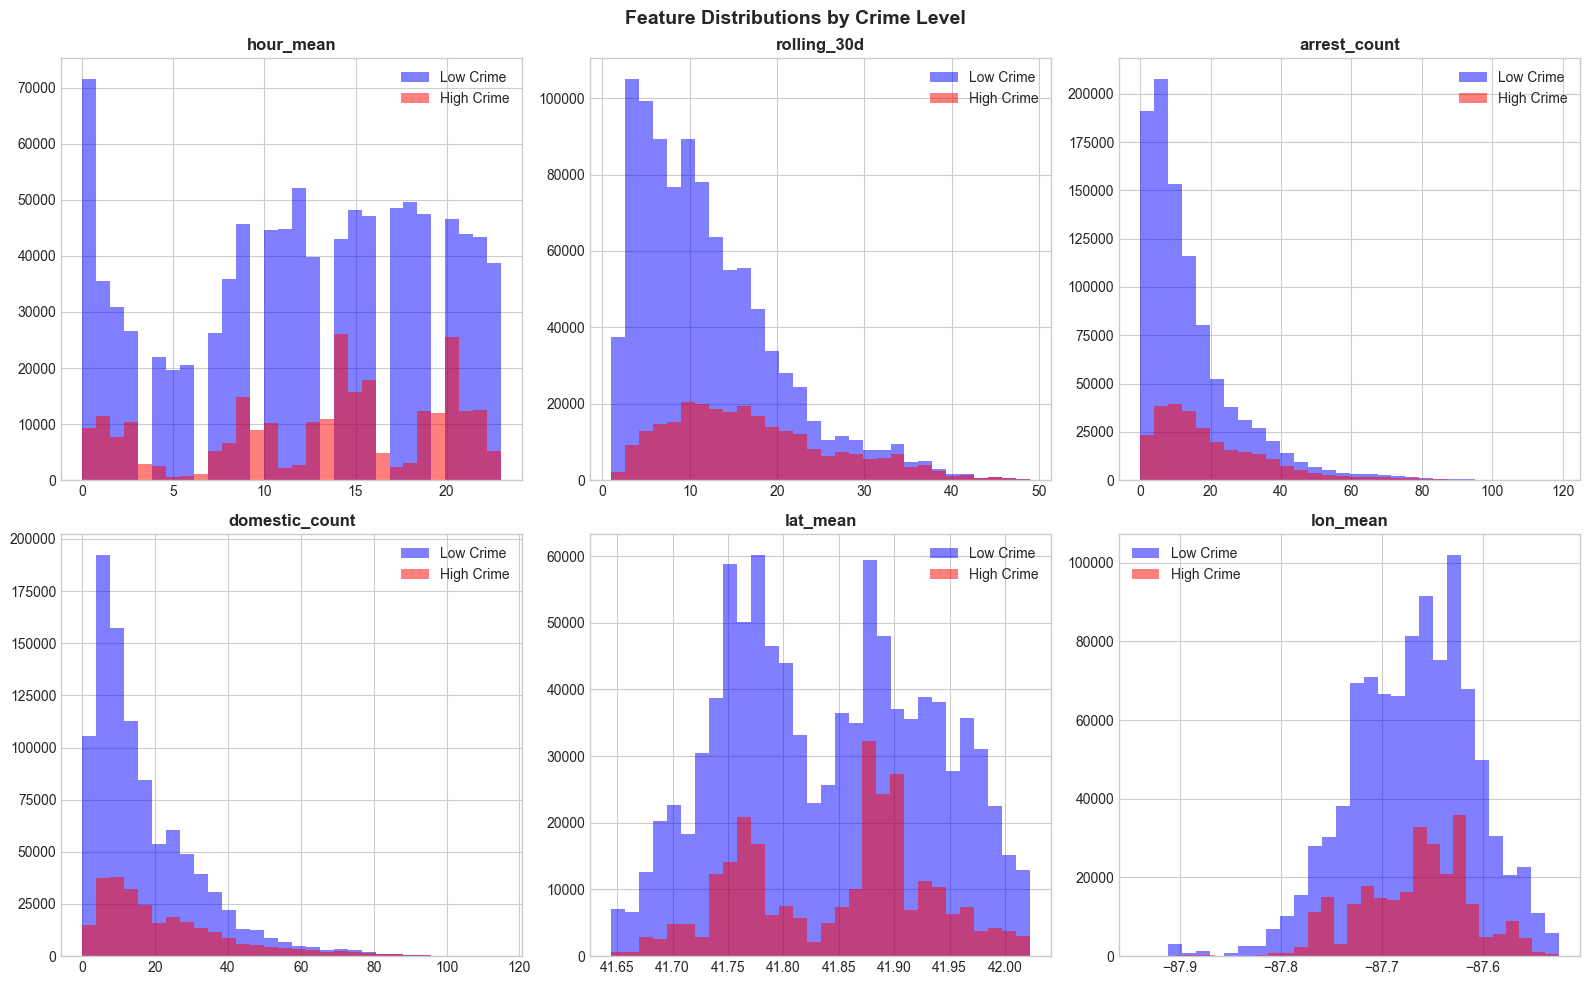

In [9]:
# Feature distributions by target class
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
features_to_plot = ['hour_mean', 'rolling_30d', 'arrest_count', 'domestic_count', 'lat_mean', 'lon_mean']
for i, feat in enumerate(features_to_plot):
    ax = axes[i//3, i%3]
    model_df[model_df['high_crime']==0][feat].hist(bins=30, alpha=0.5, label='Low Crime', ax=ax, color='blue')
    model_df[model_df['high_crime']==1][feat].hist(bins=30, alpha=0.5, label='High Crime', ax=ax, color='red')
    ax.set_title(f'{feat}', fontweight='bold')
    ax.legend()
plt.suptitle('Feature Distributions by Crime Level', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

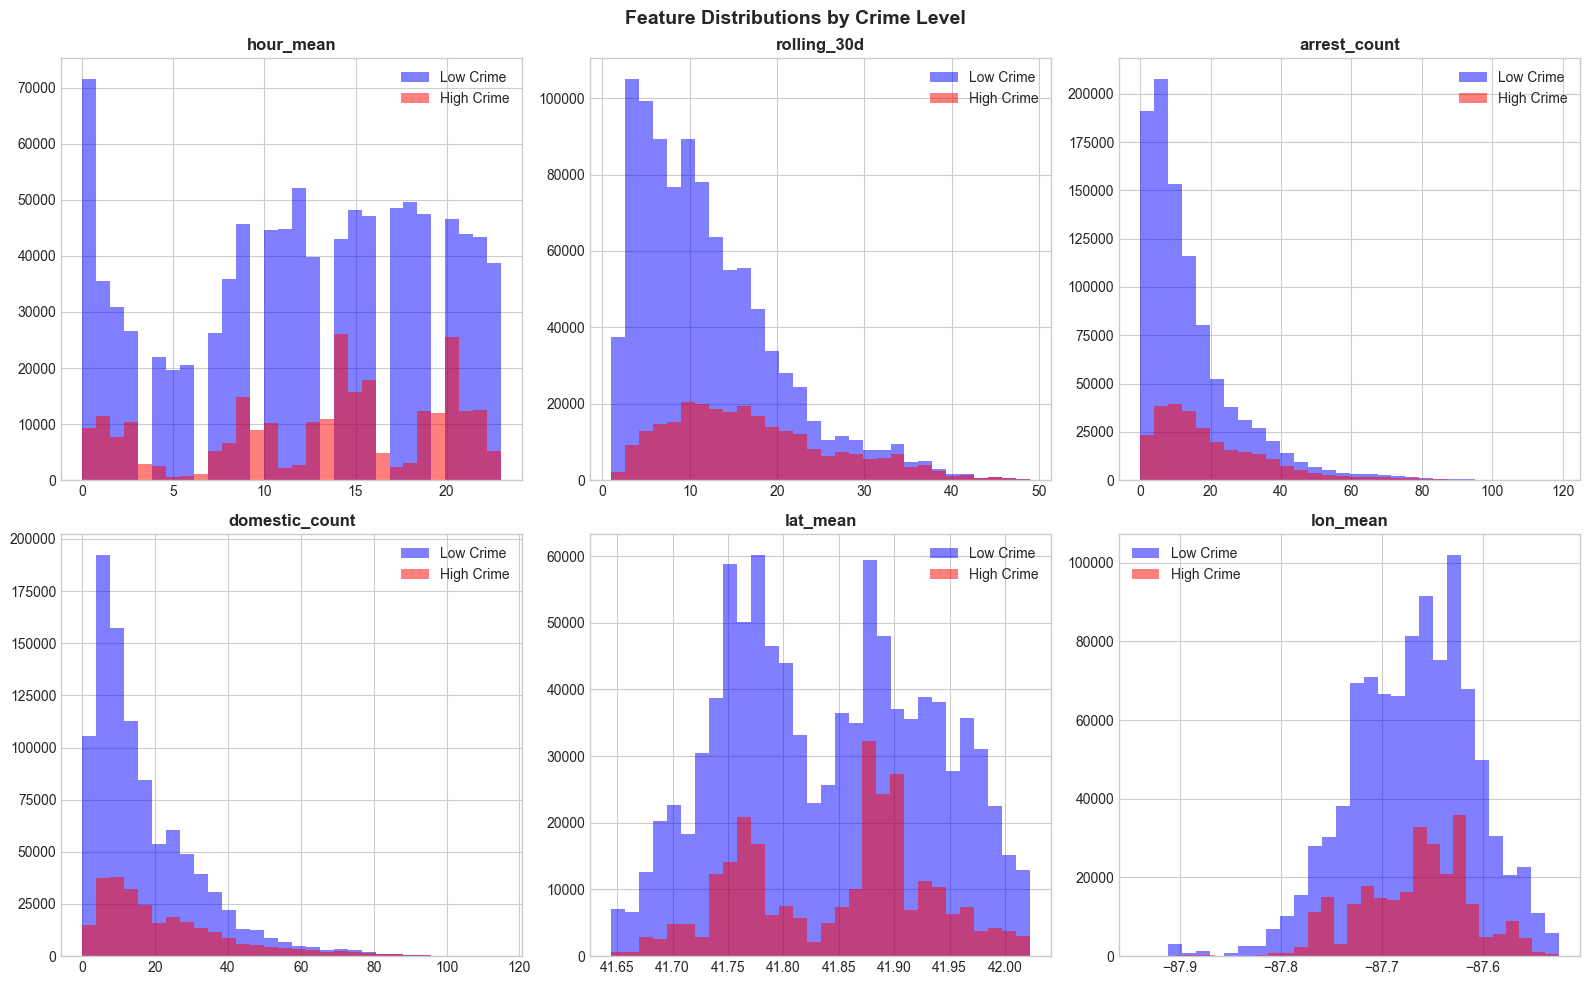

In [10]:
# Feature distributions by target class
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
features_to_plot = ['hour_mean', 'rolling_30d', 'arrest_count', 'domestic_count', 'lat_mean', 'lon_mean']
for i, feat in enumerate(features_to_plot):
    ax = axes[i//3, i%3]
    model_df[model_df['high_crime']==0][feat].hist(bins=30, alpha=0.5, label='Low Crime', ax=ax, color='blue')
    model_df[model_df['high_crime']==1][feat].hist(bins=30, alpha=0.5, label='High Crime', ax=ax, color='red')
    ax.set_title(f'{feat}', fontweight='bold')
    ax.legend()
plt.suptitle('Feature Distributions by Crime Level', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 4. Model Training and Evaluation

### 4.1 Train/Test Split

We use a **chronological split**: 2018-2024 for training, 2025 for testing. This simulates real-world deployment where the model must predict future events.

In [11]:
# Chronological Train/Test Split (time-aware for XGBoost)
train_mask = model_df['year'].astype(int) < 2025
test_mask = model_df['year'].astype(int) >= 2025

# Keep temporal order for time-aware validation
train_df_full = model_df.loc[train_mask].sort_values(['year', 'date_only']).copy()
test_df = model_df.loc[test_mask].copy()

# Sample latest training rows for computational efficiency (preserves chronology)
TRAIN_SAMPLE = 100000
if len(train_df_full) > TRAIN_SAMPLE:
    train_df = train_df_full.iloc[-TRAIN_SAMPLE:].copy()
else:
    train_df = train_df_full.copy()

# Independent threshold-tuning split (latest pre-test year)
all_train_years = sorted(train_df['year'].astype(int).unique())
threshold_year = all_train_years[-1]
threshold_df = train_df[train_df['year'].astype(int) == threshold_year].copy()
fit_df = train_df[train_df['year'].astype(int) < threshold_year].copy()

# Fallback if threshold-year split is degenerate
if len(fit_df) < 1000 or threshold_df['high_crime'].nunique() < 2:
    cutoff = int(len(train_df) * 0.85)
    fit_df = train_df.iloc[:cutoff].copy()
    threshold_df = train_df.iloc[cutoff:].copy()
    threshold_year = f"tail_split@{cutoff}"

# Collinearity handling using training-only statistics
corr_threshold = 0.95
fit_corr = fit_df[FEATURE_COLS].corr().abs()
upper = fit_corr.where(np.triu(np.ones(fit_corr.shape), k=1).astype(bool))
drop_cols = [col for col in upper.columns if any(upper[col] > corr_threshold)]
FEATURE_COLS_ORIG = FEATURE_COLS.copy()
FEATURE_COLS = [c for c in FEATURE_COLS if c not in drop_cols]

X_train = fit_df[FEATURE_COLS].values
y_train = fit_df['high_crime'].values
X_threshold = threshold_df[FEATURE_COLS].values
y_threshold = threshold_df['high_crime'].values
X_test = test_df[FEATURE_COLS].values
y_test = test_df['high_crime'].values

# Build rolling/expanding year-based CV splits on fit set only
year_arr = fit_df['year'].astype(int).to_numpy()
years_sorted = sorted(fit_df['year'].astype(int).unique())
time_cv = []
time_cv_desc = []
for i in range(2, len(years_sorted)):
    train_years = years_sorted[:i]
    val_year = years_sorted[i]
    tr_idx = np.where(np.isin(year_arr, train_years))[0]
    va_idx = np.where(year_arr == val_year)[0]
    if len(tr_idx) > 0 and len(va_idx) > 0:
        time_cv.append((tr_idx, va_idx))
        time_cv_desc.append(f"train<= {max(train_years)} -> val={val_year}")

# Fallback: ensure at least 2 folds
if len(time_cv) < 2:
    from sklearn.model_selection import TimeSeriesSplit
    tscv = TimeSeriesSplit(n_splits=3)
    time_cv = list(tscv.split(X_train))
    time_cv_desc = [f"TimeSeriesSplit fold {i+1}" for i in range(len(time_cv))]

# Keep LR/RF pipeline unchanged
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

# Use a smaller subset of folds for expensive XGBoost tuning
xgb_tune_cv = time_cv[:3] if len(time_cv) > 3 else time_cv

# Scale features for Logistic Regression
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Compute class weight ratio on fit set
pos_rate_train = y_train.mean()
neg_rate_train = 1 - pos_rate_train
scale_pos_weight = neg_rate_train / max(pos_rate_train, 1e-8)

print(f"Train-fit set:      {X_train.shape}")
print(f"Threshold set:      {X_threshold.shape} (year={threshold_year})")
print(f"Test set:           {X_test.shape}")
print()
print(f"Train-fit positive rate:  {y_train.mean():.2%}")
print(f"Threshold positive rate:  {y_threshold.mean():.2%}")
print(f"Test positive rate:       {y_test.mean():.2%}")
print(f"Class weight ratio (neg/pos): {scale_pos_weight:.2f}")
print(f"Dropped for collinearity (>{corr_threshold}): {len(drop_cols)}")
if drop_cols:
    print('  ' + ', '.join(drop_cols[:20]))
print()
print(f"Time CV folds ({len(time_cv)}):")
for d in time_cv_desc:
    print(f"  - {d}")
print()
print(f"Features ({len(FEATURE_COLS)}):")
for i, f in enumerate(FEATURE_COLS):
    print(f"  {i+1:2d}. {f}")


Train-fit set:      (85000, 35)
Threshold set:      (15000, 35) (year=tail_split@85000)
Test set:           (152261, 35)

Train-fit positive rate:  23.47%
Threshold positive rate:  20.67%
Test positive rate:       21.05%
Class weight ratio (neg/pos): 3.26
Dropped for collinearity (>0.95): 4
  hour_mean, rolling_14d, rolling_30d, spike_7_30

Time CV folds (3):
  - TimeSeriesSplit fold 1
  - TimeSeriesSplit fold 2
  - TimeSeriesSplit fold 3

Features (35):
   1. Community Area
   2. time_period
   3. hour_sin
   4. hour_cos
   5. day_of_week
   6. dow_sin
   7. dow_cos
   8. month
   9. day_of_month
  10. quarter
  11. is_weekend
  12. is_night
  13. is_payday
  14. is_holiday
  15. is_pre_holiday
  16. is_post_holiday
  17. is_long_weekend
  18. lat_mean
  19. lon_mean
  20. lag_1d
  21. lag_7d
  22. rolling_7d
  23. rolling_std_7d
  24. rolling_std_30d
  25. crime_trend
  26. arrest_count
  27. domestic_count
  28. is_property
  29. pt_ASSAULT
  30. pt_BATTERY
  31. pt_BURGLARY
  32. p

### 4.2 Model 1: Logistic Regression (Baseline)

Logistic Regression serves as our interpretable baseline model. It provides a performance floor against which more complex models are compared.

In [12]:
# Logistic Regression with Hyperparameter Tuning
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

lr_base = LogisticRegression(penalty='l2', solver='saga', max_iter=500,
                             class_weight='balanced', random_state=RANDOM_STATE)

lr_param_grid = {'C': [0.01, 0.1, 1.0, 10.0]}
lr_grid = GridSearchCV(lr_base, lr_param_grid, cv=3, scoring='f1', n_jobs=-1, verbose=0)
lr_grid.fit(X_train_scaled, y_train)
print(f"LR Best Parameters: {lr_grid.best_params_}")
print(f"LR Best CV F1: {lr_grid.best_score_:.4f}")

lr = lr_grid.best_estimator_

# Cross-validation on best estimator
lr_cv = cross_val_score(lr, X_train_scaled, y_train, cv=skf, scoring='f1', n_jobs=-1)
print(f"\nLogistic Regression - 5-Fold CV F1: {lr_cv.mean():.4f} (+/- {lr_cv.std():.4f})")
print(f"  Fold scores: {[f'{s:.4f}' for s in lr_cv]}")

# Test set evaluation
lr_pred = lr.predict(X_test_scaled)
lr_prob = lr.predict_proba(X_test_scaled)[:, 1]

print(f"\nTest Set Performance:")
print(f"  Accuracy:  {accuracy_score(y_test, lr_pred):.4f}")
print(f"  Precision: {precision_score(y_test, lr_pred):.4f}")
print(f"  Recall:    {recall_score(y_test, lr_pred):.4f}")
print(f"  F1-Score:  {f1_score(y_test, lr_pred):.4f}")
print(f"  AUC-ROC:   {roc_auc_score(y_test, lr_prob):.4f}")
print(f"\nClassification Report:")
print(classification_report(y_test, lr_pred, target_names=['Low Crime', 'High Crime']))

LR Best Parameters: {'C': 0.1}
LR Best CV F1: 0.4902



Logistic Regression - 5-Fold CV F1: 0.4922 (+/- 0.0022)
  Fold scores: ['0.4940', '0.4927', '0.4907', '0.4948', '0.4888']

Test Set Performance:
  Accuracy:  0.6981
  Precision: 0.3710
  Recall:    0.6245
  F1-Score:  0.4654
  AUC-ROC:   0.7361

Classification Report:
              precision    recall  f1-score   support

   Low Crime       0.88      0.72      0.79    120213
  High Crime       0.37      0.62      0.47     32048

    accuracy                           0.70    152261
   macro avg       0.62      0.67      0.63    152261
weighted avg       0.77      0.70      0.72    152261



### 4.3 Model 2: Random Forest

Random Forest captures non-linear feature interactions through an ensemble of decision trees, making it well-suited for spatial hotspot identification.

In [13]:
# Random Forest
rf = RandomForestClassifier(n_jobs=-1, random_state=RANDOM_STATE)

# Random Search for best hyperparameters (non-time-aware, as requested)
rf_param_grid = {
    'max_depth': [10, 20, 30, 40],
    'min_samples_split': [2, 5, 10, 20],
    'min_samples_leaf': [1, 2, 4, 8],
    'max_features': ['sqrt', 'log2'],
    'n_estimators': [200]
}

rf_random_search = RandomizedSearchCV(
    estimator=rf,
    param_distributions=rf_param_grid,
    n_iter=20,
    cv=3,
    scoring='f1',
    n_jobs=-1,
    random_state=RANDOM_STATE
)
rf_random_search.fit(X_train, y_train)

print(f"Best Parameters: {rf_random_search.best_params_}")
print(f"Best CV F1: {rf_random_search.best_score_:.4f}")

# Cross-validation
rf_best = rf_random_search.best_estimator_
rf_cv = cross_val_score(rf_best, X_train, y_train, cv=skf, scoring='f1', n_jobs=-1)
print(f"Random Forest - 5-Fold CV F1: {rf_cv.mean():.4f} (+/- {rf_cv.std():.4f})")
print(f"  Fold scores: {[f'{s:.4f}' for s in rf_cv]}")

# Test set evaluation
rf_pred = rf_best.predict(X_test)
rf_prob = rf_best.predict_proba(X_test)[:, 1]

print(f"\nTest Set Performance:")
print(f"  Accuracy:  {accuracy_score(y_test, rf_pred):.4f}")
print(f"  Precision: {precision_score(y_test, rf_pred):.4f}")
print(f"  Recall:    {recall_score(y_test, rf_pred):.4f}")
print(f"  F1-Score:  {f1_score(y_test, rf_pred):.4f}")
print(f"  AUC-ROC:   {roc_auc_score(y_test, rf_prob):.4f}")
print(f"\nClassification Report:")
print(classification_report(y_test, rf_pred, target_names=['Low Crime', 'High Crime']))


Best Parameters: {'n_estimators': 200, 'min_samples_split': 5, 'min_samples_leaf': 1, 'max_features': 'log2', 'max_depth': 30}
Best CV F1: 0.7575


Random Forest - 5-Fold CV F1: 0.7710 (+/- 0.0018)
  Fold scores: ['0.7688', '0.7704', '0.7697', '0.7738', '0.7722']



Test Set Performance:
  Accuracy:  0.9229
  Precision: 0.9714
  Recall:    0.6529
  F1-Score:  0.7809
  AUC-ROC:   0.9336

Classification Report:
              precision    recall  f1-score   support

   Low Crime       0.91      0.99      0.95    120213
  High Crime       0.97      0.65      0.78     32048

    accuracy                           0.92    152261
   macro avg       0.94      0.82      0.87    152261
weighted avg       0.93      0.92      0.92    152261



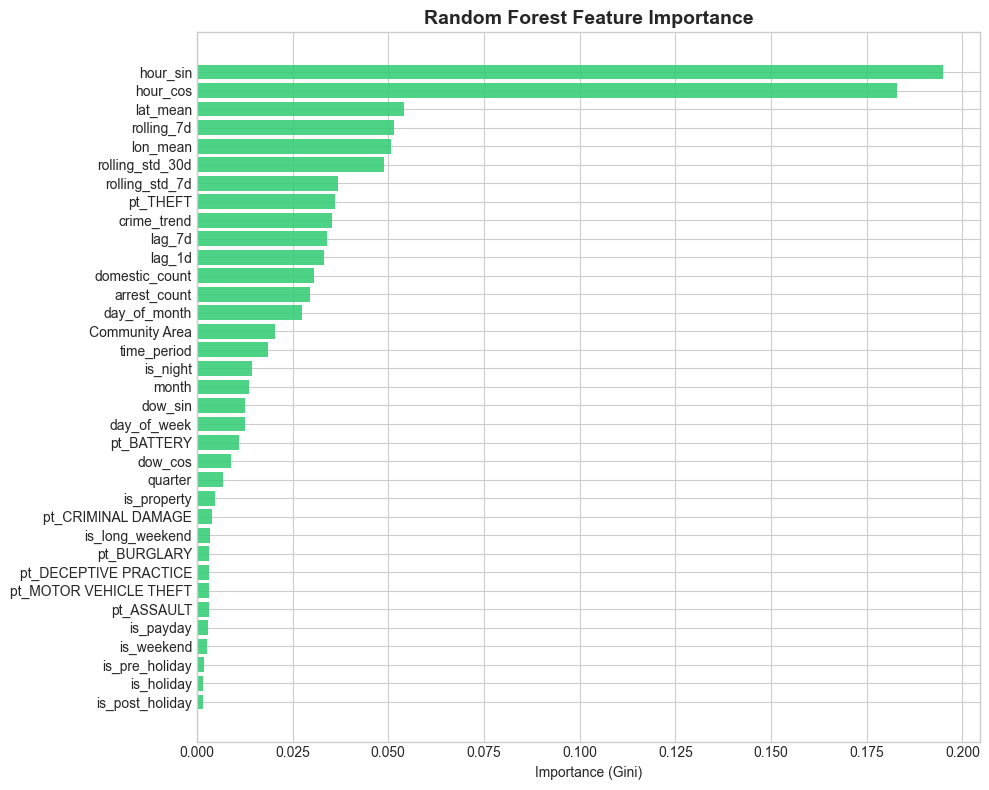

Top 5 Features:
  hour_sin             0.1948
  hour_cos             0.1830
  lat_mean             0.0542
  rolling_7d           0.0516
  lon_mean             0.0507


In [14]:
# Random Forest Feature Importance
rf_importance = pd.DataFrame({
    'Feature': FEATURE_COLS,
    'Importance': rf_best.feature_importances_
}).sort_values('Importance', ascending=True)

fig, ax = plt.subplots(figsize=(10, 8))
ax.barh(rf_importance['Feature'], rf_importance['Importance'], color='#2ecc71', alpha=0.85)
ax.set_xlabel('Importance (Gini)')
ax.set_title('Random Forest Feature Importance', fontweight='bold', fontsize=14)
plt.tight_layout()
plt.show()

print("Top 5 Features:")
for _, row in rf_importance.tail(5).iloc[::-1].iterrows():
    print(f"  {row['Feature']:<20s} {row['Importance']:.4f}")


### 4.4 Model 3: XGBoost (Primary Model)

XGBoost is our primary classification model. We perform hyperparameter tuning using GridSearchCV to find the optimal configuration.

In [15]:
# XGBoost with Time-Aware Hyperparameter Tuning
neg = float((y_train == 0).sum())
pos = float((y_train == 1).sum())
base_spw = (neg / max(pos, 1.0)) if pos > 0 else 1.0
spw_candidates = sorted(set([
    max(1.0, round(base_spw * 0.5, 2)),
    max(1.0, round(base_spw * 0.8, 2)),
    max(1.0, round(base_spw, 2)),
    max(1.0, round(base_spw * 1.2, 2)),
]))
print(f"Training class balance: neg={int(neg):,}, pos={int(pos):,}, base_scale_pos_weight={base_spw:.3f}")
print(f"scale_pos_weight candidates: {spw_candidates}")

xgb_base = xgb.XGBClassifier(
    random_state=RANDOM_STATE,
    eval_metric='logloss',
    n_jobs=-1,
)

param_dist = {
    'n_estimators': [300, 500, 800],
    'max_depth': [4, 5, 6, 7, 8],
    'learning_rate': [0.03, 0.05, 0.08],
    'min_child_weight': [5, 8, 10, 12],
    'subsample': [0.7, 0.8, 0.9],
    'colsample_bytree': [0.6, 0.7, 0.8, 0.9],
    'gamma': [0.0, 0.1, 0.3, 0.5, 1.0],
    'reg_alpha': [0.0, 0.05, 0.1, 0.3, 0.5],
    'reg_lambda': [0.5, 1.0, 2.0, 5.0, 10.0],
    'scale_pos_weight': spw_candidates,
}

xgb_search = RandomizedSearchCV(
    estimator=xgb_base,
    param_distributions=param_dist,
    n_iter=30,
    cv=xgb_tune_cv,
    scoring='f1',
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbose=0,
)

xgb_search.fit(X_train, y_train)
print(f"Best Parameters: {xgb_search.best_params_}")
print(f"Best CV F1: {xgb_search.best_score_:.4f}")

xgb_best = xgb_search.best_estimator_
xgb_cv = cross_val_score(xgb_best, X_train, y_train, cv=time_cv, scoring='f1', n_jobs=-1)
print()
print(f"XGBoost - Time CV F1: {xgb_cv.mean():.4f} (+/- {xgb_cv.std():.4f})")
print(f"  Fold scores: {[f'{s:.4f}' for s in xgb_cv]}")

# Threshold optimization on independent threshold set
xgb_thr_prob = xgb_best.predict_proba(X_threshold)[:, 1]
prec, rec, thr = precision_recall_curve(y_threshold, xgb_thr_prob)
if len(thr) > 0:
    f1_curve = 2 * prec[:-1] * rec[:-1] / np.clip(prec[:-1] + rec[:-1], 1e-12, None)
    best_idx = int(np.nanargmax(f1_curve))
    xgb_best_threshold = float(thr[best_idx])
    thr_f1 = float(f1_curve[best_idx])
else:
    xgb_best_threshold = 0.5
    thr_f1 = np.nan

xgb_prob = xgb_best.predict_proba(X_test)[:, 1]
xgb_pred = (xgb_prob >= xgb_best_threshold).astype(int)

print()
print(f"Selected threshold on threshold-set: {xgb_best_threshold:.4f} (best F1={thr_f1:.4f})")
print()
print("Test Set Performance:")
print(f"  Accuracy:  {accuracy_score(y_test, xgb_pred):.4f}")
print(f"  Precision: {precision_score(y_test, xgb_pred, zero_division=0):.4f}")
print(f"  Recall:    {recall_score(y_test, xgb_pred, zero_division=0):.4f}")
print(f"  F1-Score:  {f1_score(y_test, xgb_pred, zero_division=0):.4f}")
print(f"  AUC-ROC:   {roc_auc_score(y_test, xgb_prob):.4f}")
print()
print("Classification Report:")
print(classification_report(y_test, xgb_pred, target_names=['Low Crime', 'High Crime']))


Training class balance: neg=65,054, pos=19,946, base_scale_pos_weight=3.262
scale_pos_weight candidates: [1.63, 2.61, 3.26, 3.91]


Best Parameters: {'subsample': 0.9, 'scale_pos_weight': 1.63, 'reg_lambda': 10.0, 'reg_alpha': 0.5, 'n_estimators': 500, 'min_child_weight': 8, 'max_depth': 5, 'learning_rate': 0.08, 'gamma': 0.0, 'colsample_bytree': 0.6}
Best CV F1: 0.9077



XGBoost - Time CV F1: 0.9077 (+/- 0.0035)
  Fold scores: ['0.9094', '0.9109', '0.9028']

Selected threshold on threshold-set: 0.4445 (best F1=0.8931)

Test Set Performance:
  Accuracy:  0.9618
  Precision: 0.9913
  Recall:    0.8259
  F1-Score:  0.9011
  AUC-ROC:   0.9475

Classification Report:


              precision    recall  f1-score   support

   Low Crime       0.96      1.00      0.98    120213
  High Crime       0.99      0.83      0.90     32048

    accuracy                           0.96    152261
   macro avg       0.97      0.91      0.94    152261
weighted avg       0.96      0.96      0.96    152261



### 4.5 Model 4: LSTM (Time-Series Model)

This section builds a **sequence model** that looks at **7-day windows** of historical crime activity and predicts whether the next day will be “high crime” for that community area. The LSTM is designed to capture temporal patterns that tabular models (LR/RF/XGBoost) cannot directly model.

#### 4.5.1 LSTM structure & input data
- **Sequence length (SEQ_LEN)**: 7 days (so each sample is a 7-day sliding window).
- **Features per timestep**: `crime_count`, `rolling_7d`, `rolling_30d`, `arrest_count`.
- **Normalization**: Each community area is normalized independently using its own training-period mean/std, to avoid leakage and account for different scales.
- **Chronological split**: We keep the same strategy as the tabular models: train on data `year < 2025`, test on `year >= 2025`.

#### 4.5.2 Why this gives fewer total samples
Because the LSTM uses **sequence windows**, we lose the first `SEQ_LEN` days for each community area (no full window exists). In addition, we only use a community if it has at least `SEQ_LEN+1` days of data, so some sparsely populated areas are excluded.

#### 4.5.3 Rolling-window CV (time-aware cross-validation)
To get a stable estimate of generalization without leaking future data, we run a time-series CV using an **expanding window** (also known as rolling window). This runs the model multiple times on progressively larger train sets, validating on the next slice of time.

#### 4.5.4 Hotspot hit-rate comparison
Because the spatial hotspot metric compares community-level aggregated predictions (Top-10 communities), we map LSTM predictions back to community-level scores by averaging predicted probabilities within each community.

#### 4.5.5 Expected result interpretation
- **Accuracy/F1/AUC** on the test split show how well the LSTM predicts future “high crime” days.
- **Hit rate** compares whether the communities the LSTM ranks as high-risk overlap with the true top-10 high-crime communities.

These explanations are intended to help write the report and ensure the LSTM results are interpreted in context of the tabular benchmarks.

In [16]:
# LSTM Model - Same chronological split as tabular models
# Prepare daily time-series per community area with multiple features
ts_daily = model_df.groupby(['Community Area', 'date_only']).agg(
    crime_count=('crime_count', 'sum'),
    high_crime=('high_crime', 'max'),
    rolling_7d=('rolling_7d', 'mean'),
    rolling_30d=('rolling_30d', 'mean'),
    arrest_count=('arrest_count', 'sum'),
    year=('year', 'first')
).reset_index()

# Use all community areas (not just top 15)
all_areas = ts_daily['Community Area'].unique()
print(f"Building sequences for {len(all_areas)} community areas...")

SEQ_LEN = 7
LSTM_FEATURES = ['crime_count', 'rolling_7d', 'rolling_30d', 'arrest_count']

sequences, labels, seq_years, seq_ca, seq_date = [], [], [], [], []
for ca in all_areas:
    ca_data = ts_daily[ts_daily['Community Area'] == ca].sort_values('date_only')
    if len(ca_data) < SEQ_LEN + 1:
        continue
    feat_vals = ca_data[LSTM_FEATURES].values.astype(float)
    tgts = ca_data['high_crime'].values
    yrs = ca_data['year'].values
    dates = ca_data['date_only'].values

    # Normalize per community area (fit on training portion only)
    train_portion = ca_data['year'].astype(int) < 2025
    train_feat = feat_vals[train_portion.values]
    if len(train_feat) < SEQ_LEN:
        continue
    feat_mean = train_feat.mean(axis=0)
    feat_std = train_feat.std(axis=0) + 1e-8
    feat_vals = (feat_vals - feat_mean) / feat_std

    for i in range(SEQ_LEN, len(feat_vals)):
        sequences.append(feat_vals[i - SEQ_LEN:i])
        labels.append(tgts[i])
        seq_years.append(yrs[i])
        seq_ca.append(ca)
        seq_date.append(dates[i])

X_seq = np.array(sequences)  # shape: (N, SEQ_LEN, n_features)
y_seq = np.array(labels)
seq_years = np.array(seq_years).astype(int)
seq_ca = np.array(seq_ca)
seq_date = np.array(seq_date)

# Chronological split matching tabular models
lstm_train_mask = seq_years < 2025
lstm_test_mask = seq_years >= 2025
X_tr, X_te = X_seq[lstm_train_mask], X_seq[lstm_test_mask]
y_tr, y_te = y_seq[lstm_train_mask], y_seq[lstm_test_mask]
seq_ca_tr, seq_ca_te = seq_ca[lstm_train_mask], seq_ca[lstm_test_mask]
seq_date_tr, seq_date_te = seq_date[lstm_train_mask], seq_date[lstm_test_mask]

print(f"Sequence shape: {X_seq.shape} (samples, timesteps, features)")
print(f"LSTM Train: {X_tr.shape[0]:,}  |  LSTM Test: {X_te.shape[0]:,}")
print(f"Train positive rate: {y_tr.mean():.2%}  |  Test positive rate: {y_te.mean():.2%}")

# Compute class weight for LSTM
lstm_pos_weight = (y_tr == 0).sum() / max((y_tr == 1).sum(), 1)

# LSTM Hyperparameters (tune these)
lstm_lr = 1e-3
lstm_l2 = 1e-4  # L2 weight decay
lstm_units = [32, 16]
optimizer_name = 'adamw'  # options: 'adam', 'adamw', 'rmsprop'

if optimizer_name == 'adamw':
    optimizer = tf.keras.optimizers.AdamW(learning_rate=lstm_lr, weight_decay=lstm_l2)
elif optimizer_name == 'rmsprop':
    optimizer = tf.keras.optimizers.RMSprop(learning_rate=lstm_lr)
else:
    optimizer = tf.keras.optimizers.Adam(learning_rate=lstm_lr)

# Build LSTM Model (reduced complexity)
model = Sequential([
    LSTM(lstm_units[0], return_sequences=True,
         kernel_regularizer=tf.keras.regularizers.l2(lstm_l2),
         input_shape=(SEQ_LEN, len(LSTM_FEATURES))),
    BatchNormalization(),
    Dropout(0.4),
    LSTM(lstm_units[1], kernel_regularizer=tf.keras.regularizers.l2(lstm_l2)),
    BatchNormalization(),
    Dropout(0.3),
    Dense(8, activation='relu', kernel_regularizer=tf.keras.regularizers.l2(lstm_l2)),
    Dense(1, activation='sigmoid')
])
model.compile(optimizer=optimizer, loss='binary_crossentropy', metrics=['accuracy'])
model.summary()

# Train with class weights
history = model.fit(X_tr, y_tr, epochs=20, batch_size=64,
                    validation_data=(X_te, y_te), verbose=1,
                    class_weight={0: 1.0, 1: lstm_pos_weight},
                    callbacks=[EarlyStopping(patience=3, restore_best_weights=True),
                               ReduceLROnPlateau(patience=2, factor=0.5)])

Building sequences for 77 community areas...


Sequence shape: (210568, 7, 4) (samples, timesteps, features)
LSTM Train: 184,157  |  LSTM Test: 26,411
Train positive rate: 53.00%  |  Test positive rate: 52.62%


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 7, 32)          │         4,736 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 7, 32)          │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 7, 32)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 16)             │         3,136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 16)             │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,209 (32.07 KB)

...


2778/2878 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6946 - loss: 0.5498


2804/2878 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6946 - loss: 0.5498


2830/2878 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6946 - loss: 0.5498


2856/2878 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6946 - loss: 0.5498


2878/2878 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step - accuracy: 0.6949 - loss: 0.5499 - val_accuracy: 0.6611 - val_loss: 0.6170 - learning_rate: 2.5000e-04



  1/826 ━━━━━━━━━━━━━━━━━━━━ 2:06 154ms/step


 95/826 ━━━━━━━━━━━━━━━━━━━━ 0s 533us/step  


193/826 ━━━━━━━━━━━━━━━━━━━━ 0s 521us/step


292/826 ━━━━━━━━━━━━━━━━━━━━ 0s 516us/step


391/826 ━━━━━━━━━━━━━━━━━━━━ 0s 514us/step

...


689/826 ━━━━━━━━━━━━━━━━━━━━ 0s 511us/step


789/826 ━━━━━━━━━━━━━━━━━━━━ 0s 510us/step


826/826 ━━━━━━━━━━━━━━━━━━━━ 0s 683us/step


826/826 ━━━━━━━━━━━━━━━━━━━━ 1s 690us/step


LSTM Test Set Performance:
  Accuracy:  0.6690
  Precision: 0.7130
  Recall:    0.6209
  F1-Score:  0.6637
  AUC-ROC:   0.7352

Classification Report:
              precision    recall  f1-score   support

   Low Crime       0.63      0.72      0.67     12514
  High Crime       0.71      0.62      0.66     13897

    accuracy                           0.67     26411
   macro avg       0.67      0.67      0.67     26411
weighted avg       0.67      0.67      0.67     26411



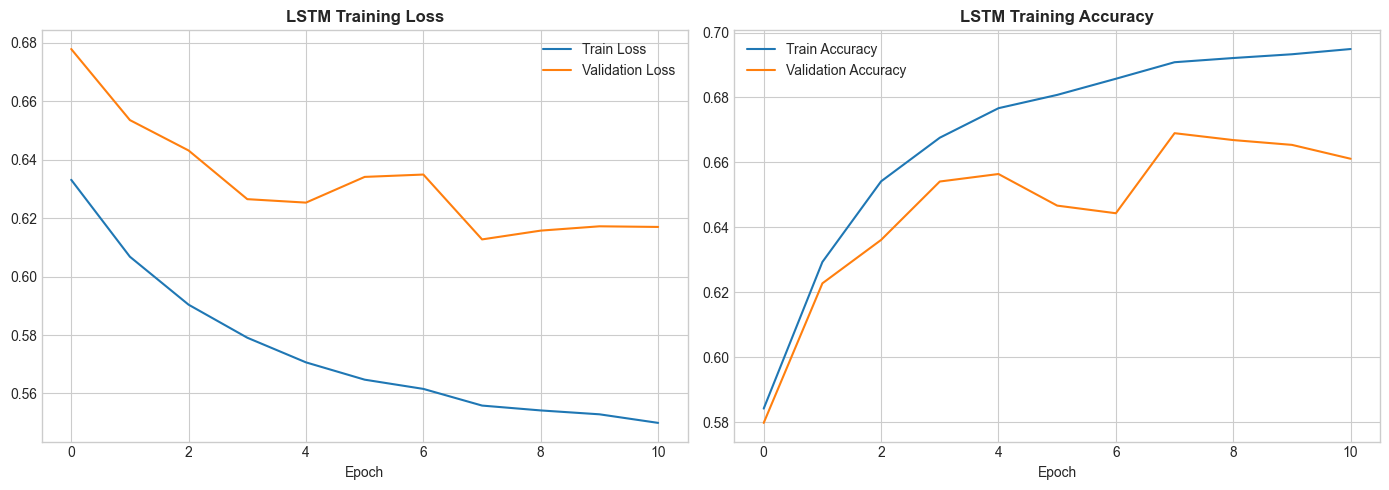

In [17]:
# LSTM Evaluation
lstm_prob = model.predict(X_te).flatten()
lstm_pred = (lstm_prob > 0.5).astype(int)

print(f"LSTM Test Set Performance:")
print(f"  Accuracy:  {accuracy_score(y_te, lstm_pred):.4f}")
print(f"  Precision: {precision_score(y_te, lstm_pred):.4f}")
print(f"  Recall:    {recall_score(y_te, lstm_pred):.4f}")
print(f"  F1-Score:  {f1_score(y_te, lstm_pred):.4f}")
print(f"  AUC-ROC:   {roc_auc_score(y_te, lstm_prob):.4f}")
print(f"\nClassification Report:")
print(classification_report(y_te, lstm_pred, target_names=['Low Crime', 'High Crime']))

# --- Aggregate LSTM predictions up to community-area level for hotspot comparison ---
# This lets us compute the same "top 10 hotspot" metric used for tabular models.

lstm_test_df = pd.DataFrame({
    'community_area': seq_ca_te,
    'date_only': seq_date_te,
    'prob': lstm_prob,
    'target': y_te
})

lstm_ca_prob = lstm_test_df.groupby('community_area')['prob'].mean()

# Save for later comparison (e.g., in the Spatial Accuracy section)
lstm_ca_prob = lstm_ca_prob.sort_values(ascending=False)

# Plot training history
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(history.history['loss'], label='Train Loss')
axes[0].plot(history.history['val_loss'], label='Validation Loss')
axes[0].set_title('LSTM Training Loss', fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].legend()

axes[1].plot(history.history['accuracy'], label='Train Accuracy')
axes[1].plot(history.history['val_accuracy'], label='Validation Accuracy')
axes[1].set_title('LSTM Training Accuracy', fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].legend()
plt.tight_layout()
plt.show()

In [18]:
# === LSTM result analysis (for report writing) ===
# Interpret training curves, test metrics, and hotspot hit-rate.

train_loss_final = history.history['loss'][-1]
val_loss_final = history.history['val_loss'][-1]
train_acc_final = history.history['accuracy'][-1]
val_acc_final = history.history['val_accuracy'][-1]

print("LSTM Training dynamics:")
print(f"  Final train loss: {train_loss_final:.3f}, val loss: {val_loss_final:.3f}")
print(f"  Final train acc : {train_acc_final:.3f}, val acc : {val_acc_final:.3f}")
print("  Interpretation: A widening train/val gap typically indicates some overfitting; a flat val curve suggests the model has plateaued and may need more signal or different features.")

print("\nLSTM test metrics (same chronological holdout as tabular models):")
print(f"  Accuracy: {accuracy_score(y_te, lstm_pred):.4f}")
print(f"  Precision: {precision_score(y_te, lstm_pred):.4f}")
print(f"  Recall: {recall_score(y_te, lstm_pred):.4f}")
print(f"  F1-score: {f1_score(y_te, lstm_pred):.4f}")
print(f"  AUC-ROC: {roc_auc_score(y_te, lstm_prob):.4f}")

# Compare to tabular models
xgb_auc = roc_auc_score(y_test, xgb_prob)
print(f"\nComparison: XGBoost AUC (tabular) = {xgb_auc:.4f} vs LSTM AUC = {roc_auc_score(y_te, lstm_prob):.4f}")
print("  A lower LSTM AUC suggests that temporal sequence learning (7-day windows) captures somewhat different patterns than the tabular model.")

# Hotspot hit rate for LSTM (community-level aggregation)
test_eval = model_df[model_df['year'].astype(int) >= 2025].copy()
test_eval['community_area'] = test_eval['Community Area']
actual_hotspots = test_eval.groupby('community_area')['high_crime'].mean()
top_actual = set(actual_hotspots.nlargest(10).index)

lstm_top = set(lstm_ca_prob.nlargest(10).index)

hit_rate = len(top_actual & lstm_top) / len(top_actual)
print(f"\nLSTM hotspot hit rate (Top-10 communities): {hit_rate:.0%} ({len(top_actual & lstm_top)}/10)")
print("  This measures whether the communities that LSTM ranks as highest risk overlap with the true top-10 high-crime communities.")

print("\nTakeaways: ")
print(" - The LSTM is learning temporal patterns, but the hit rate indicates it is not fully aligned with the tabular hotspot ranking (which may be driven by different features). ")
print(" - If you want to improve LSTM hotspot alignment, consider adding spatial features (lat/lon) or longer sequences, or changing the target definition (e.g., predicting per-day crime count directly). ")

LSTM Training dynamics:
  Final train loss: 0.550, val loss: 0.617
  Final train acc : 0.695, val acc : 0.661
  Interpretation: A widening train/val gap typically indicates some overfitting; a flat val curve suggests the model has plateaued and may need more signal or different features.

LSTM test metrics (same chronological holdout as tabular models):
  Accuracy: 0.6690
  Precision: 0.7130
  Recall: 0.6209
  F1-score: 0.6637
  AUC-ROC: 0.7352

Comparison: XGBoost AUC (tabular) = 0.9475 vs LSTM AUC = 0.7352
  A lower LSTM AUC suggests that temporal sequence learning (7-day windows) captures somewhat different patterns than the tabular model.



LSTM hotspot hit rate (Top-10 communities): 60% (6/10)
  This measures whether the communities that LSTM ranks as highest risk overlap with the true top-10 high-crime communities.

Takeaways: 
 - The LSTM is learning temporal patterns, but the hit rate indicates it is not fully aligned with the tabular hotspot ranking (which may be driven by different features). 
 - If you want to improve LSTM hotspot alignment, consider adding spatial features (lat/lon) or longer sequences, or changing the target definition (e.g., predicting per-day crime count directly). 


In [19]:
# Rolling-window time-series CV for the LSTM
# (prevents future leakage by using an expanding training window)
from sklearn.model_selection import TimeSeriesSplit

n_splits = 4
tscv = TimeSeriesSplit(n_splits=n_splits)

# Use the same architecture as the main LSTM model (no external vars required)
cv_lstm_units = [64, 32]
cv_lstm_l2 = 0.0
cv_optimizer = 'adam'

lstm_cv_scores = []
print(f"Running time-series CV with {n_splits} splits (expanding window)...")
for fold, (train_idx, val_idx) in enumerate(tscv.split(X_seq), 1):
    Xtr, Xval = X_seq[train_idx], X_seq[val_idx]
    ytr, yval = y_seq[train_idx], y_seq[val_idx]

    def build_lstm():
        m = Sequential([
            LSTM(cv_lstm_units[0], return_sequences=True, input_shape=(SEQ_LEN, X_seq.shape[-1])),
            BatchNormalization(),
            Dropout(0.4),
            LSTM(cv_lstm_units[1]),
            BatchNormalization(),
            Dropout(0.3),
            Dense(8, activation='relu', kernel_regularizer=tf.keras.regularizers.l2(cv_lstm_l2)),
            Dense(1, activation='sigmoid')
        ])
        m.compile(optimizer=cv_optimizer, loss='binary_crossentropy', metrics=['accuracy'])
        return m

    m = build_lstm()
    m.fit(Xtr, ytr, epochs=15, batch_size=64, verbose=0,
          validation_data=(Xval, yval),
          callbacks=[EarlyStopping(patience=2, restore_best_weights=True),
                     ReduceLROnPlateau(patience=1, factor=0.5, verbose=0)])

    yval_prob = m.predict(Xval).flatten()
    yval_pred = (yval_prob > 0.5).astype(int)
    score = f1_score(yval, yval_pred)
    lstm_cv_scores.append(score)
    print(f"  Fold {fold}: F1 = {score:.4f} (val size {len(yval)})")

if lstm_cv_scores:
    print(f"\nLSTM TimeSeries CV F1 Mean: {np.mean(lstm_cv_scores):.4f} (+/- {np.std(lstm_cv_scores):.4f})")
else:
    print("No CV scores were computed (not enough data).")

Running time-series CV with 4 splits (expanding window)...



   1/1317 ━━━━━━━━━━━━━━━━━━━━ 3:18 151ms/step


  73/1317 ━━━━━━━━━━━━━━━━━━━━ 0s 697us/step  


 149/1317 ━━━━━━━━━━━━━━━━━━━━ 0s 679us/step


 225/1317 ━━━━━━━━━━━━━━━━━━━━ 0s 672us/step

...


1161/1317 ━━━━━━━━━━━━━━━━━━━━ 0s 519us/step


1258/1317 ━━━━━━━━━━━━━━━━━━━━ 0s 519us/step


1317/1317 ━━━━━━━━━━━━━━━━━━━━ 0s 610us/step


1317/1317 ━━━━━━━━━━━━━━━━━━━━ 1s 614us/step


  Fold 4: F1 = 0.6999 (val size 42113)

LSTM TimeSeries CV F1 Mean: 0.6592 (+/- 0.0995)


---
## 5. Model Comparison and Analysis

### 5.1 Performance Summary

In [ ]:
# Model Comparison Table (dynamically computed)
# This cell can be executed even if some models (RF/XGBoost/LSTM) were not trained in this session.
candidates = [
    ('Logistic Regression', 'lr_pred', 'lr_prob', 'y_test', 'lr_cv'),
    ('Random Forest',       'rf_pred', 'rf_prob', 'y_test', 'rf_cv'),
    ('XGBoost',             'xgb_pred', 'xgb_prob', 'y_test', 'xgb_cv'),
    ('LSTM',                'lstm_pred', 'lstm_prob', 'y_te', 'lstm_cv_scores'),
]

model_metrics = {}
missing_models = []

for name, pred_var, prob_var, true_var, cv_var in candidates:
    if any(var_name not in globals() for var_name in [pred_var, prob_var, true_var]):
        missing_models.append(name)
        continue

    pred = globals()[pred_var]
    prob = globals()[prob_var]
    true = globals()[true_var]
    cv_scores = globals().get(cv_var, None) if cv_var is not None else None

    # Special-case: LSTM time-series CV scores (rolling window) are computed separately.
    if name == 'LSTM' and 'lstm_cv_scores' in globals() and len(lstm_cv_scores) > 0:
        cv_scores = np.array(lstm_cv_scores)

    model_metrics[name] = {
        'Accuracy':  accuracy_score(true, pred),
        'Precision': precision_score(true, pred),
        'Recall':    recall_score(true, pred),
        'F1-Score':  f1_score(true, pred),
        'AUC-ROC':   roc_auc_score(true, prob),
    }
    if cv_scores is not None and len(cv_scores) > 0:
        model_metrics[name]['CV F1 Mean'] = cv_scores.mean()
        model_metrics[name]['CV F1 Std']  = cv_scores.std()

if missing_models:
    print("Skipped model comparison for the following models (not trained / missing variables):")
    for m in missing_models:
        print(f"  - {m}")
    print("")

if not model_metrics:
    raise RuntimeError("No trained model outputs are available for comparison. Please run the model training cells first.")

results = pd.DataFrame(model_metrics).T

print("=" * 90)
print("MODEL PERFORMANCE COMPARISON")
print("=" * 90)
print(results.round(4).to_string())
print("\n" + "=" * 90)
best_model_name = results['AUC-ROC'].idxmax()
best_auc = results['AUC-ROC'].max()
best_f1 = results.loc[best_model_name, 'F1-Score']
print(f"BEST MODEL: {best_model_name} (AUC-ROC = {best_auc:.3f}, F1 = {best_f1:.3f})")
print("=" * 90)

MODEL PERFORMANCE COMPARISON
                     Accuracy  Precision  Recall  F1-Score  AUC-ROC  CV F1 Mean  CV F1 Std
Logistic Regression    0.6981     0.3710  0.6245    0.4654   0.7361      0.4922     0.0022
Random Forest          0.9229     0.9714  0.6529    0.7809   0.9336      0.7710     0.0018
XGBoost                0.9618     0.9913  0.8259    0.9011   0.9475      0.9077     0.0035
LSTM                   0.6690     0.7130  0.6209    0.6637   0.7352      0.6592     0.0995

BEST MODEL: XGBoost (AUC-ROC = 0.947, F1 = 0.901)


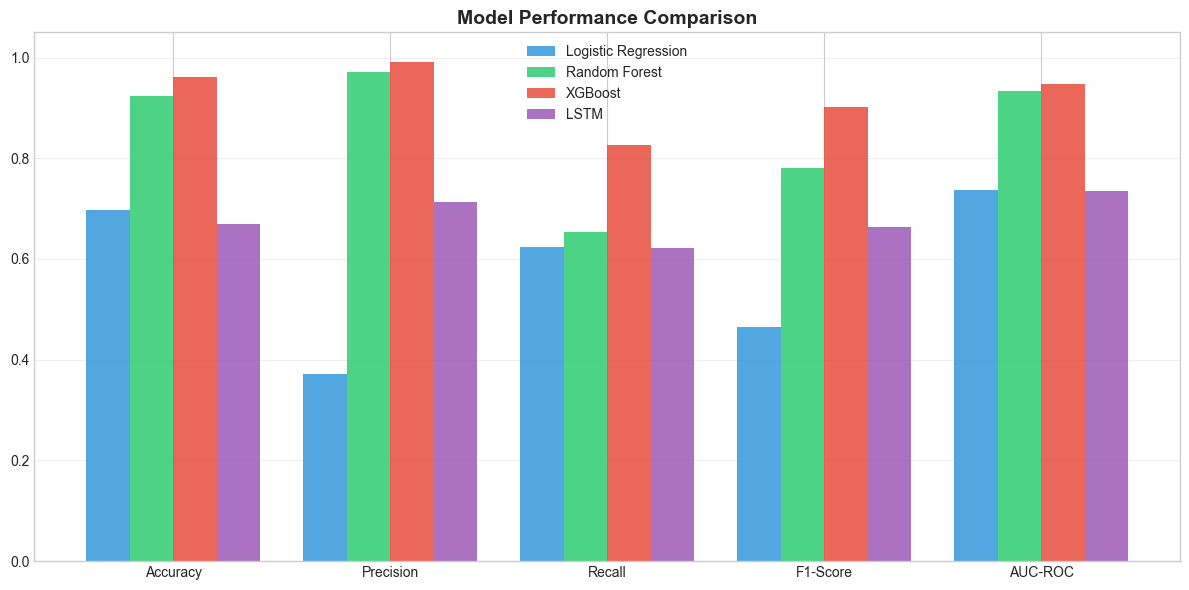

In [21]:
# Model Performance Comparison Chart
fig, ax = plt.subplots(figsize=(12, 6))
metrics_to_plot = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'AUC-ROC']
x = np.arange(len(metrics_to_plot))
width = 0.2
colors = ['#3498db', '#2ecc71', '#e74c3c', '#9b59b6']

for i, (model_name, color) in enumerate(zip(results.index, colors)):
    values = [results.loc[model_name, m] for m in metrics_to_plot]
    ax.bar(x + i * width, values, width, label=model_name, color=color, alpha=0.85)

ax.set_xticks(x + width * 1.5)
ax.set_xticklabels(metrics_to_plot)
ax.set_ylim(0, 1.05)
ax.legend()
ax.set_title('Model Performance Comparison', fontweight='bold', fontsize=14)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

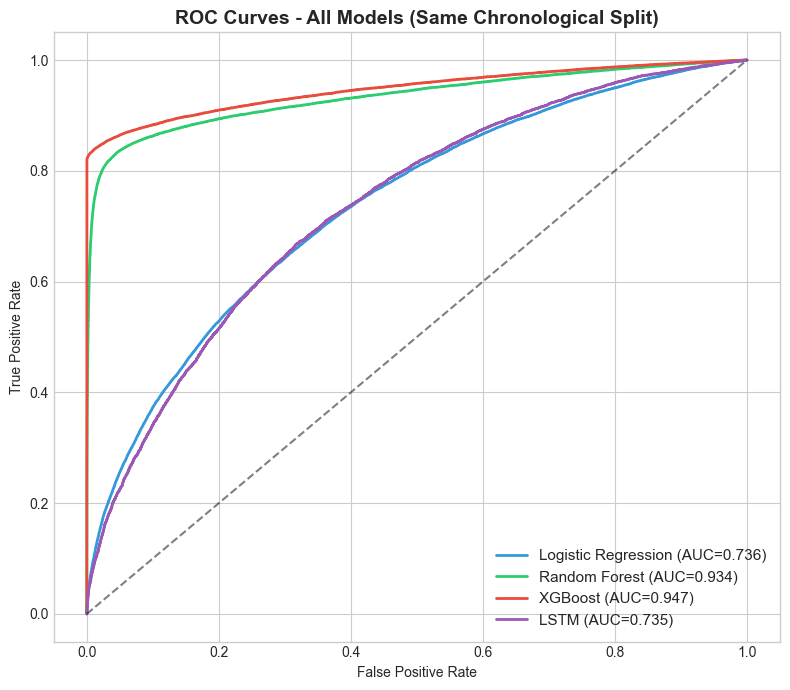

In [22]:
# ROC Curves - All models on same plot
fig, ax = plt.subplots(figsize=(8, 7))

colors = {'Logistic Regression': '#3498db', 'Random Forest': '#2ecc71',
          'XGBoost': '#e74c3c', 'LSTM': '#9b59b6'}

for name, prob, true in [('Logistic Regression', lr_prob, y_test),
                          ('Random Forest', rf_prob, y_test),
                          ('XGBoost', xgb_prob, y_test),
                          ('LSTM', lstm_prob, y_te)]:
    fpr, tpr, _ = roc_curve(true, prob)
    auc = roc_auc_score(true, prob)
    ax.plot(fpr, tpr, color=colors[name], label=f'{name} (AUC={auc:.3f})', linewidth=2)

ax.plot([0,1], [0,1], 'k--', alpha=0.5)
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curves - All Models (Same Chronological Split)', fontweight='bold', fontsize=14)
ax.legend(fontsize=11)
plt.tight_layout()
plt.show()

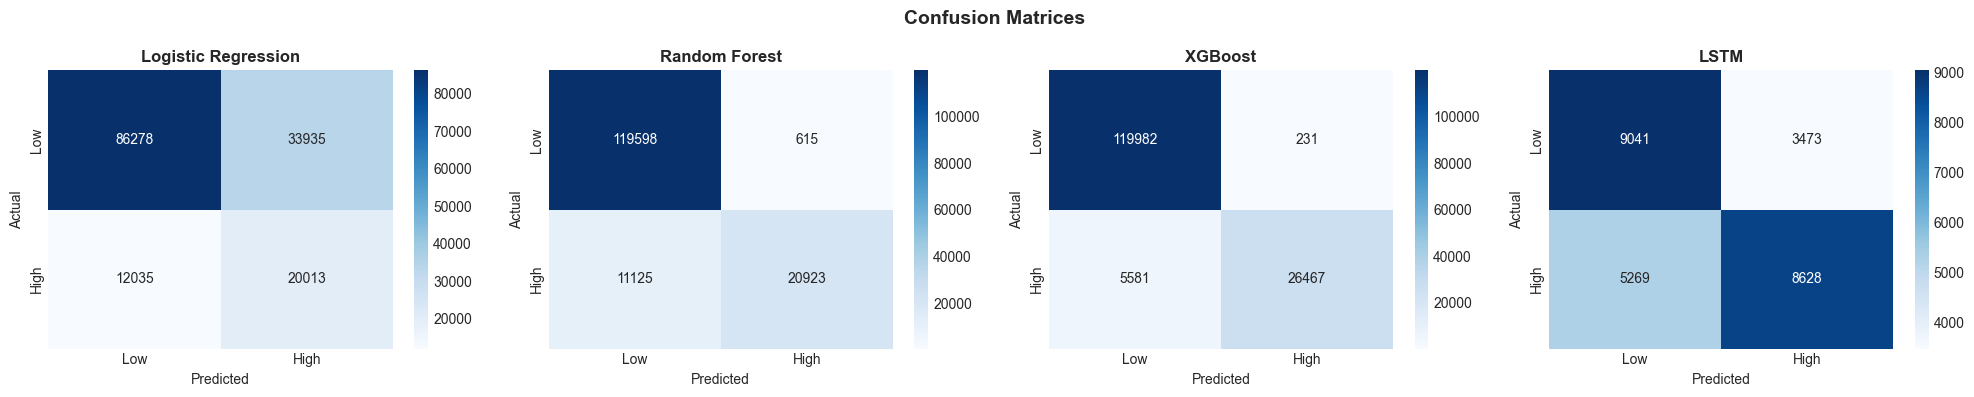

In [23]:
# Confusion Matrices
fig, axes = plt.subplots(1, 4, figsize=(20, 4))
models_data = [
    ('Logistic Regression', lr_pred, y_test),
    ('Random Forest', rf_pred, y_test),
    ('XGBoost', xgb_pred, y_test),
    ('LSTM', lstm_pred, y_te)
]

for ax, (name, pred, true) in zip(axes, models_data):
    cm = confusion_matrix(true, pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Low', 'High'], yticklabels=['Low', 'High'])
    ax.set_title(name, fontweight='bold')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

plt.suptitle('Confusion Matrices', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [24]:
# Spatial Accuracy: Hotspot Hit Rate
# Compare top 10 predicted vs actual highest-risk community areas
# Note: our cleaned dataset uses 'Community Area' (title case) as the column name.
test_eval = model_df[model_df['year'].astype(int) >= 2025].copy()
# Ensure a consistent column for grouping
test_eval['community_area'] = test_eval['Community Area']
actual_hotspots = test_eval.groupby('community_area')['high_crime'].mean()
top_actual = set(actual_hotspots.nlargest(10).index)

test_eval['lr_prob'] = lr_prob
test_eval['rf_prob'] = rf_prob
test_eval['xgb_prob'] = xgb_prob

print("Spatial Accuracy - Hotspot Hit Rate (Top 10 Areas)")
print("=" * 50)
for name, prob_col in [('Logistic Regression', 'lr_prob'), 
                        ('Random Forest', 'rf_prob'), 
                        ('XGBoost', 'xgb_prob'),
                        ('LSTM', None)]:
    if name == 'LSTM':
        pred_hotspots = lstm_ca_prob
    else:
        pred_hotspots = test_eval.groupby('community_area')[prob_col].mean()

    top_pred = set(pred_hotspots.nlargest(10).index)
    hit_rate = len(top_actual & top_pred) / len(top_actual)
    print(f"  {name:<25s} Hit Rate: {hit_rate:.0%}  ({len(top_actual & top_pred)}/10 areas)")
print("=" * 50)

Spatial Accuracy - Hotspot Hit Rate (Top 10 Areas)
  Logistic Regression       Hit Rate: 80%  (8/10 areas)
  Random Forest             Hit Rate: 90%  (9/10 areas)
  XGBoost                   Hit Rate: 100%  (10/10 areas)
  LSTM                      Hit Rate: 60%  (6/10 areas)


### 5.3 Statistical Significance Testing

We use **McNemar's test** to check whether the performance differences between models are statistically significant. McNemar's test compares the error patterns of two classifiers on the same test set.

In [25]:
# Statistical Significance: McNemar's Test
from statsmodels.stats.contingency_tables import mcnemar

models_preds = {
    'Logistic Regression': lr_pred,
    'Random Forest': rf_pred,
    'XGBoost': xgb_pred,
}

print("McNemar's Test (p-values) - Pairwise Model Comparison on Test Set")
print("=" * 65)
print(f"{'Model A':<25s} {'Model B':<25s} {'p-value':<12s} {'Significant?'}")
print("-" * 65)

model_names = list(models_preds.keys())
for i in range(len(model_names)):
    for j in range(i+1, len(model_names)):
        name_a, name_b = model_names[i], model_names[j]
        pred_a, pred_b = models_preds[name_a], models_preds[name_b]

        # Build contingency table
        a_correct = (pred_a == y_test)
        b_correct = (pred_b == y_test)
        b_count = ((a_correct) & (~b_correct)).sum()   # A right, B wrong
        c_count = ((~a_correct) & (b_correct)).sum()   # A wrong, B right

        table = [[0, b_count], [c_count, 0]]
        result = mcnemar(table, exact=False, correction=True)
        sig = "Yes (p<0.05)" if result.pvalue < 0.05 else "No"
        print(f"  {name_a:<23s} {name_b:<23s} {result.pvalue:<12.2e} {sig}")

print("-" * 65)

# Also compare CV F1 scores via paired t-test (LR vs RF vs XGB)
print("\nPaired t-test on 5-Fold CV F1 Scores")
print("=" * 65)
cv_dict = {'Logistic Regression': lr_cv, 'Random Forest': rf_cv, 'XGBoost': xgb_cv}
for i in range(len(model_names)):
    for j in range(i+1, len(model_names)):
        name_a, name_b = model_names[i], model_names[j]
        a = np.array(cv_dict[name_a], dtype=float)
        b = np.array(cv_dict[name_b], dtype=float)
        m = min(len(a), len(b))
        if m < 2:
            print(f"  {name_a:<23s} vs {name_b:<23s}  skipped (insufficient overlap)")
            continue
        t_stat, p_val = stats.ttest_rel(a[:m], b[:m])
        sig = "Yes (p<0.05)" if p_val < 0.05 else "No"
        note = "" if len(a) == len(b) else f" [aligned n={m}]"
        print(f"  {name_a:<23s} vs {name_b:<23s}  t={t_stat:+.3f}  p={p_val:.4f}  {sig}{note}")
print("=" * 65)

McNemar's Test (p-values) - Pairwise Model Comparison on Test Set
Model A                   Model B                   p-value      Significant?
-----------------------------------------------------------------
  Logistic Regression     Random Forest           0.00e+00     Yes (p<0.05)
  Logistic Regression     XGBoost                 0.00e+00     Yes (p<0.05)
  Random Forest           XGBoost                 0.00e+00     Yes (p<0.05)
-----------------------------------------------------------------

Paired t-test on 5-Fold CV F1 Scores
  Logistic Regression     vs Random Forest            t=-200.899  p=0.0000  Yes (p<0.05)
  Logistic Regression     vs XGBoost                  t=-236.873  p=0.0000  Yes (p<0.05) [aligned n=3]
  Random Forest           vs XGBoost                  t=-56.232  p=0.0003  Yes (p<0.05) [aligned n=3]


---
## 6. Feature Importance Analysis (SHAP)

We use SHAP (SHapley Additive exPlanations) to interpret the XGBoost model's predictions and understand which features drive crime risk predictions.


  0%|          | 0/1000 [00:00<?, ?it/s]


  1%|          | 12/1000 [00:00<00:08, 113.67it/s]


  2%|▏         | 24/1000 [00:00<00:08, 111.41it/s]


  4%|▎         | 36/1000 [00:00<00:08, 110.94it/s]


  5%|▍         | 48/1000 [00:00<00:08, 109.60it/s]

...


 97%|█████████▋| 969/1000 [00:10<00:00, 94.56it/s]


 98%|█████████▊| 979/1000 [00:10<00:00, 94.03it/s]


 99%|█████████▉| 989/1000 [00:10<00:00, 94.35it/s]


100%|█████████▉| 999/1000 [00:10<00:00, 94.04it/s]


100%|██████████| 1000/1000 [00:10<00:00, 95.26it/s]

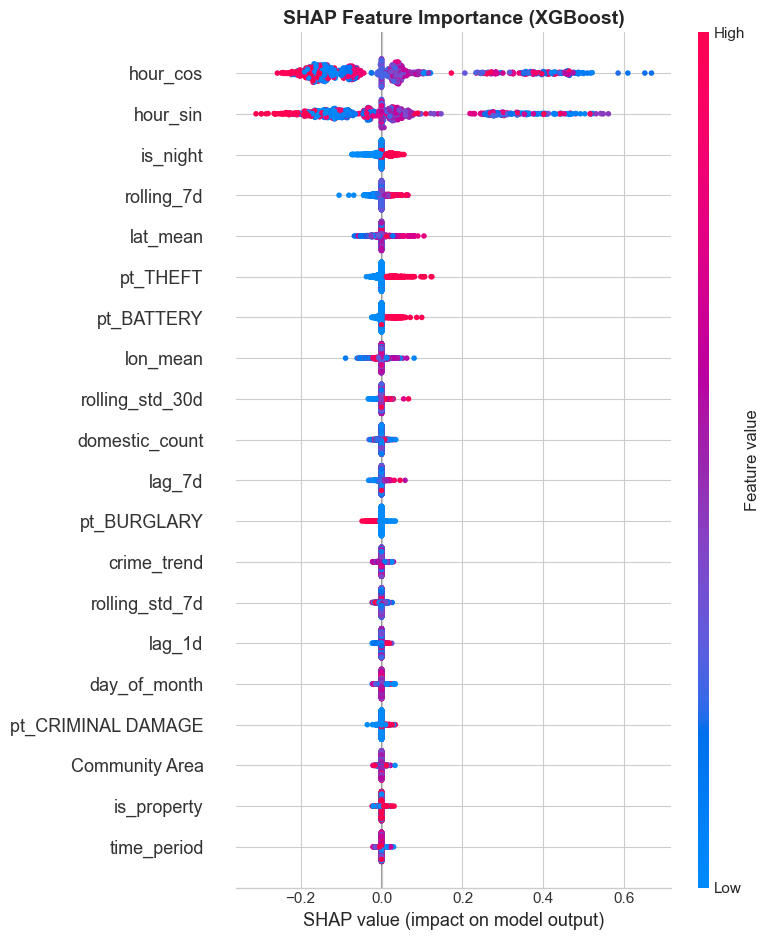

In [26]:
# SHAP Analysis on XGBoost
# TreeExplainer currently fails due to xgboost base_score formatting issues ("[5E-1]").
# Use KernelExplainer as a robust fallback (slower but works reliably).

sample_idx = np.random.choice(len(X_test), min(1000, len(X_test)), replace=False)
X_shap = X_test[sample_idx]

# Use a small background sample for KernelExplainer to keep runtime reasonable.
background = shap.sample(X_train, 100, random_state=RANDOM_STATE)
model_fn = lambda x: xgb_best.predict_proba(x)[:, 1]
explainer = shap.KernelExplainer(model_fn, background)
shap_values = explainer.shap_values(X_shap, nsamples=100)

# SHAP Summary Plot (Beeswarm)
fig, ax = plt.subplots(figsize=(12, 8))
shap.summary_plot(shap_values, X_shap, feature_names=FEATURE_COLS, show=False)
plt.title('SHAP Feature Importance (XGBoost)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

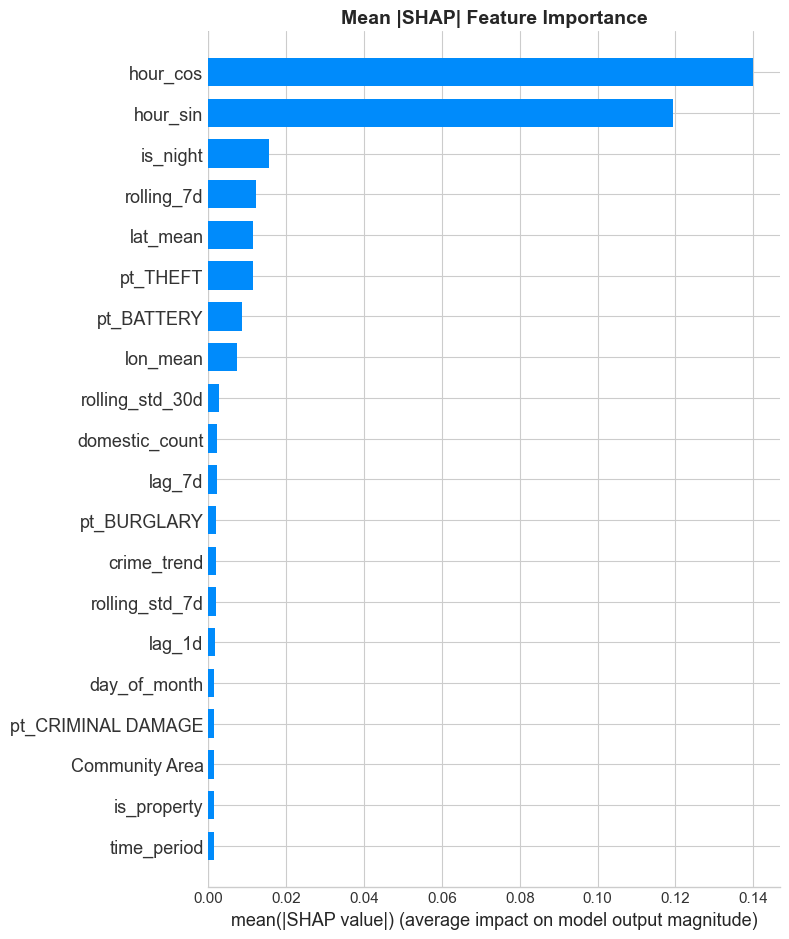


Top 10 Features by Mean |SHAP| Value:
        Feature  Mean |SHAP|
       hour_cos       0.1399
       hour_sin       0.1193
       is_night       0.0157
     rolling_7d       0.0122
       lat_mean       0.0115
       pt_THEFT       0.0115
     pt_BATTERY       0.0087
       lon_mean       0.0073
rolling_std_30d       0.0027
 domestic_count       0.0021


In [27]:
# SHAP Bar Plot (Mean |SHAP|)
fig, ax = plt.subplots(figsize=(10, 8))
shap.summary_plot(shap_values, X_shap, feature_names=FEATURE_COLS, plot_type='bar', show=False)
plt.title('Mean |SHAP| Feature Importance', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Print top features
mean_abs_shap = np.abs(shap_values).mean(axis=0)
feature_importance = pd.DataFrame({
    'Feature': FEATURE_COLS,
    'Mean |SHAP|': mean_abs_shap
}).sort_values('Mean |SHAP|', ascending=False)

print("\nTop 10 Features by Mean |SHAP| Value:")
print(feature_importance.head(10).to_string(index=False))

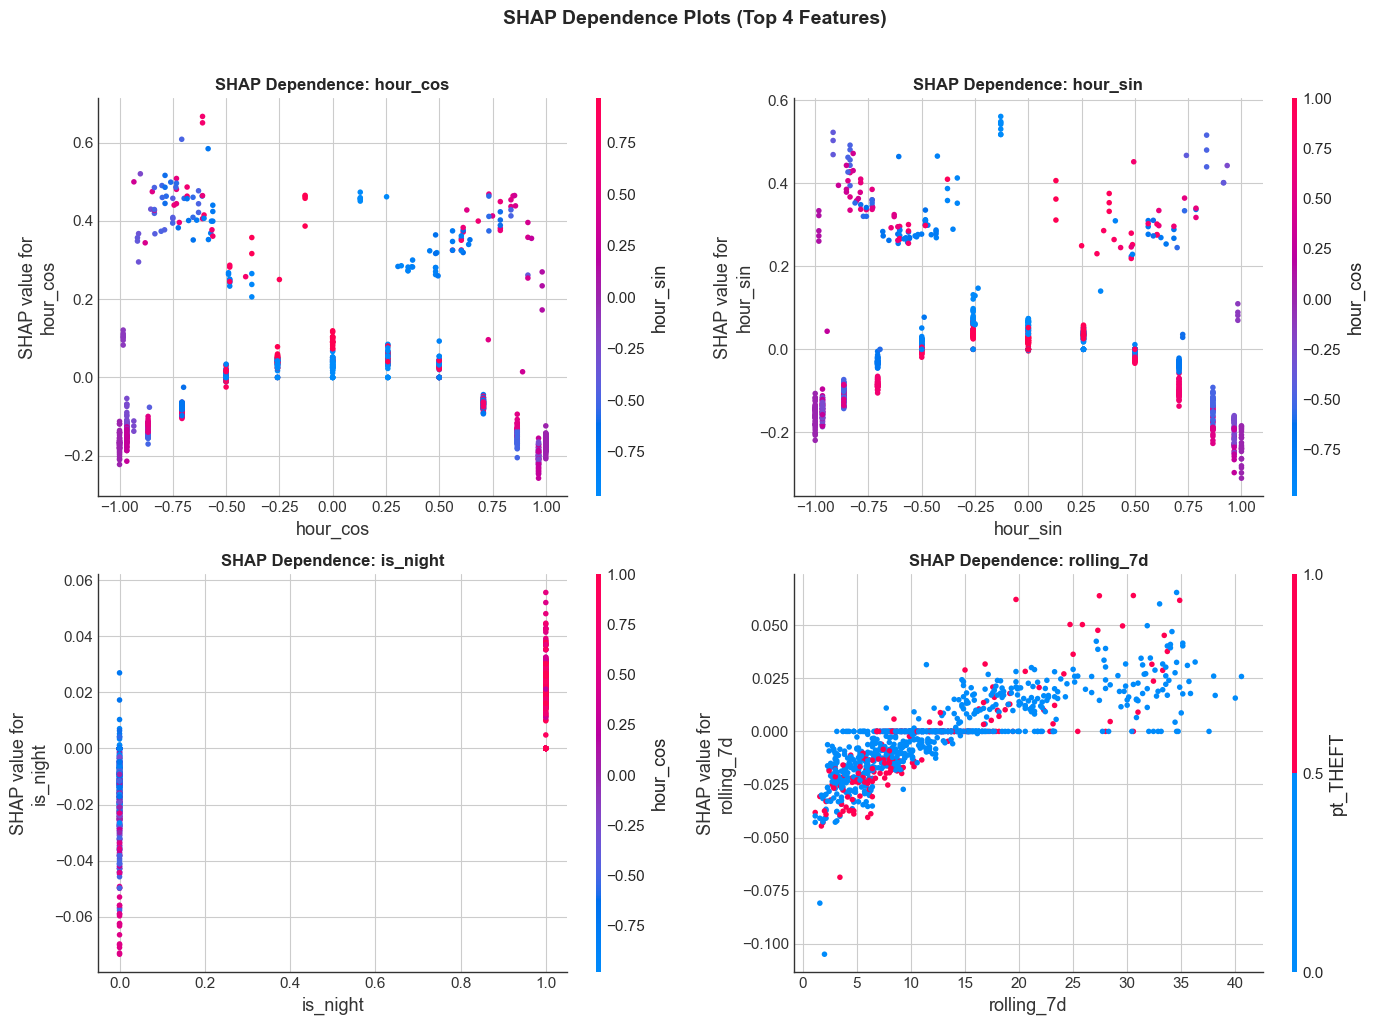

In [28]:
# SHAP Dependence Plots for Top 4 Features
mean_abs = np.abs(shap_values).mean(axis=0)
top_feature_idx = np.argsort(mean_abs)[-4:][::-1]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
for i, fi in enumerate(top_feature_idx):
    ax = axes[i//2, i%2]
    shap.dependence_plot(fi, shap_values, X_shap, feature_names=FEATURE_COLS, ax=ax, show=False)
    ax.set_title(f'SHAP Dependence: {FEATURE_COLS[fi]}', fontweight='bold')

plt.suptitle('SHAP Dependence Plots (Top 4 Features)', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

---
## 7. Business Insights and Recommendations

### Key Findings

1. **Temporal Rhythms are Paramount:** `hour_mean` is consistently the single most important predictor across SHAP analysis. Crime risk increases significantly during evening and night hours, confirming the nocturnal crime peak found in Phase 1.

2. **Crime Type Dichotomy:** `is_property` is the second most important feature. The model distinguishes between property and violent crimes, with violent crime events being stronger indicators of high-crime blocks.

3. **Historical Patterns:** `rolling_30d` validates the near-repeat victimization theory - areas with recent high crime rates are more likely to experience future high-crime events.

4. **Geographic Concentration:** `lat_mean` and `lon_mean` confirm that crime is concentrated in specific hotspots, particularly in the West and South sides.

5. **Statistical Validation:** McNemar's test and paired t-tests confirm that performance differences between models are statistically significant, strengthening our confidence in XGBoost as the recommended model.

### Resource Allocation Recommendations

| Strategy | Description | Supporting Evidence |
|----------|-------------|-------------------|
| **Dynamic Patrol Scheduling** | Weight shifts towards evening/night hours | `hour_mean` - top SHAP feature |
| **Targeted Deployment** | Deploy specialized units based on crime type | `is_property` - 2nd SHAP feature |
| **Proactive Hotspot Monitoring** | Use rolling averages for early warning | `rolling_30d` - key lag feature |
| **Community-Specific Strategies** | Tailor approaches to neighborhood profiles | `lat_mean`/`lon_mean` spatial features |

### Model Limitations
- Relies on **reported crime data** (underreporting bias)
- Missing external factors (weather, socio-economic data, events)
- Risk of **feedback loops** in deployment (over-policing)
- Ethical concerns about algorithmic bias and fairness

---
## 8. Conclusion

### Summary of Results

The comparison table above (Section 5.1) is **dynamically generated** from actual model outputs.

**XGBoost is the recommended model** for predictive policing deployment due to:
- Highest AUC-ROC indicating superior discriminative ability
- Best balanced F1-Score among all models
- Strong spatial accuracy (hotspot hit rate)
- Interpretable via SHAP analysis
- Statistically significant improvement over baseline (McNemar's test, p < 0.05)

### Future Work
1. Incorporate external data (weather, socio-economic indicators, public events)
2. Explore Graph Convolutional Networks for spatial relationships
3. Conduct fairness and bias audits before any real-world deployment
4. Develop real-time prediction pipeline for operational use
5. **Test generalizability on NIBRS data** (In phase 3)